Project description:Early student drop out Risk prediction.
Dataset:Open university learning analytic dataset(OULAD)
Name:Perecharla prasad
Group:1
Mentor:Mr Sajith.
Group leader:Mr.Shujath.

Problem statement:
1.Explain:Online student can disengage before completing a course.
2.The objective is to identify students at risk of drop out early.
3.our prediction point is 25% of course completion time line
4.the system should help identify high risk students early enough for intervention.

Project objective: To predict the risk of student dropout in a course using machine learning techniques.

3. Project Objective

Have 3–5 clear objectives, for example:

1. Integrate relevant OULAD datasets.
2. Prepare the dataset using cleaning, merging and aggregation.
3. Perform univariate and bivariate EDA.
4. Create meaningful early-warning features available at 25%.
5. Build and compare Logistic Regression, Random Forest and XGBoost.
6. Select the best model based on appropriate evaluation metrics.

Content:
This dataset belongs to Open University Online Learning Platform (Also called as "Virtual Learning Environment(VLE)") that off-campus students use for accessing the course content, forum discussions, sending assessments and checking out assignment marks etc. It consists of 7 selected courses (mentioned as modules in the dataset). Different presentations indicated with letters "B" and "J" after year for semester 2 and semester 1 respectively.
#Additionally, the dataset includes student demographics such as location, age group, disability, education level, gender etc.
Student assessment marks, interactions with the Virtual Learning Environment (VLE) are also included.

4. Dataset Description

Show the OULAD datasets you used.

A good visual would be:

#Raw data files 

#Student Info → Registration → Courses → Assessment → Student Assessment → VLE → Student VLE

#I  merged,aggregated and handled missing values and duplicated values removal done For creating  master dataset based on problem statement as student drop out risk at 25% course completion.
# I used left merge option  with common key to avoid more data genaration like duplicated values as well overfitting problems.
# Based on 25% early drop rate , Vle,Studentvle,assessment,courses data set filtes used to aggregate data with out loosing data.
#Merged studentinfo,Student registration dataset based on code_module and code_presentation with student_ID common key.
#

Also mention:

* Number of records
* Number of features
* Target variable
* Important identifiers

#assessments.csv dataset shape and info: 206 rows × 6 columns

#code_module:
Identification code of the module, to which the assessment belongs.
#code_presentation:
Identification code of the presentation, to which the assessment belongs.
#d_assessment:
Identification number of the assessment.
assessment_type:
 Three types of assessments exist: Tutor Marked Assessment (TMA), Computer Marked
#Date:
Information about the final submission date of the assessment calculated as the number of days since the start of
#weight:
Weight of the assessment in %. Typically, Exams are treated separately and have the weight 100%;





#Courses.csv dataset shape and info:Shape: (22, 3)
#Code_module   :code name of the module (known as unit code in many universities), which serves as the identifier.               
#code_presentation   :code_presentation
code name of the presentation. It consists of the year and “B” for the presentation starting in February          
#module_presentation_length :Length of the module-presentation in days.

#Student assessment.csv shape and details about dataset:(173912, 5)
This file contains the results of students’ assessments. If the student does not submit the assessment, no result is recorded. The final exam submissions are missing, if the result of the assessments is not stored in the system.
#id_assessment      : The identification number of the assessment.
#id_student         : A unique identification number for the student.
#date_submitted     : The date of student submission, measured as the number of days since the start of the module presentation.
#is_banked          : A status flag indicating that the assessment result has been transferred from a previous presentation.
#score              :The student’s score in this assessment. The range is from 0 to 100. The score lower than 40 is interpreted as Fail. The marks are in the range


#studentinfo.csv:Shape: (32593, 12)
This file contains demographic information about the students together with their results.
code_module:An identification code for a module on which the student is registered.
#code_presentation:
The identification code of the presentation during which the student is registered on the module.
cation number for the student.
#id_student
A unique identification of student
#Gender:Students gender
#Region:Identifies the geographic region, where the student lived while taking the module-presentation.
#highest_education:
Highest student education level on entry to the module presentation.
#imd_band:
Specifies the Index of Multiple Depravation band of the place where the student lived during the module-presentation
#age_band:
Band of the student’s age.
#num_of_prev_attempts:
The number times the student has attempted this module.
#studied_credits:
The total number of credits for the modules the student is currently studying.
#Disability:Physical condition of students
#Final_Result:Final result of each student as pass,fail,withdraw etc.




#studenRegistration:Shape: (32593, 5)
#This file contains information about the time when the student registered for the module presentation. For students who unregistered the date of deregistration is also recorded.
#Code_module   :code name of the module (known as unit code in many universities), which serves as the identifier.               
#code_presentation   :code_presentation
code name of the presentation. It consists of the year and “B” for the presentation starting in February 
#Id_student: Unique identification number of student.
#date_registration
The date of student’s registration on the module presentation, this is the number of days measured relative to the project object
#Date_unregisteration:date_unregistration
Date of student unregistration from the module presentation, this is the number of days measured relative to the project object as 25% course completed or dropped before.


#Vle.csv dataset shape and description:Shape: (6364, 6)
#id_site:
An identification number of the material.
#code_module:
An identification code for the module that the material is related to.
#code_presentation:
The identification code of presentation of the module.
#activity_type:
The role associated with the module material.
#Week_from:
The week from which the material is planned to be used.
Week_to:
Week until which the material is planned to be used.

#StudentVle.csv dataset description:Shape: (195585, 6)
#Code_module   :code name of the module (known as unit code in many universities), which serves as the identifier.               
#code_presentation   :code_presentation
code name of the presentation. It consists of the year and “B” for the presentation starting in February 
#Id_student: Unique identification number of student.
#id_site
An identification number for the VLE material.
#date:
The date of student’s interaction with the material measured as the number of days since the start of the module.
#sum_click:
The number of times a student interacts with the material in that day.


In [ ]:
import pandas as pd
from pathlib import Path

# Load the requested CSV files from the workspace directory
base_dir = Path.cwd()

files = {
    "assessments": "assessments.csv",
    "courses": "courses.csv",
    "studentinfo": "studentInfo.csv",
    "studentregistration": "studentRegistration.csv",
    "vle": "vle.csv",
    "studentvle": "studentVle.csv",
    "studentassessment": "studentAssessment.csv",
}

for name, filename in files.items():
    path = base_dir / filename
    if not path.exists():
        raise FileNotFoundError(f"{filename} not found at {path}")
    globals()[name] = pd.read_csv(path)
    print(f"{name}: {globals()[name].shape[0]} rows × {globals()[name].shape[1]} columns")




assessments: 206 rows × 6 columns
courses: 22 rows × 3 columns
studentinfo: 32593 rows × 12 columns
studentregistration: 32593 rows × 5 columns
vle: 6364 rows × 6 columns
studentvle: 195585 rows × 6 columns
studentassessment: 173912 rows × 5 columns


In [ ]:
df_names = ["assessments", "courses", "studentinfo", "studentregistration", "vle", "studentvle", "studentassessment"]

for name in df_names:
    df = globals()[name]
    print(f"\n{'=' * 80}")
    print(f"{name.upper()}" )
    print(f"{'=' * 80}")
    print("Shape:", df.shape)
    print("\nInfo:")
    df.info(verbose=False)
    print("\nMissing values:")
    print(df.isna().sum())
    print("\nDuplicate rows:", df.duplicated().sum())



ASSESSMENTS
Shape: (206, 6)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Columns: 6 entries, code_module to weight
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB

Missing values:
code_module           0
code_presentation     0
id_assessment         0
assessment_type       0
date                 11
weight                0
dtype: int64

Duplicate rows: 0

COURSES
Shape: (22, 3)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Columns: 3 entries, code_module to module_presentation_length
dtypes: int64(1), object(2)
memory usage: 656.0+ bytes

Missing values:
code_module                   0
code_presentation             0
module_presentation_length    0
dtype: int64

Duplicate rows: 0

STUDENTINFO
Shape: (32593, 12)

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Columns: 12 entries, code_module to final_result
dtypes: int64(3), object(9)
memory usage: 3.0+ MB

Missing values:
c

In [ ]:
summary = []
for name in df_names:
    df = globals()[name]
    summary.append({
        "DataFrame": name,
        "Shape": df.shape,
        "Columns": list(df.columns),
        "Missing Values": int(df.isna().sum().sum()),
        "Missing by Column": df.isna().sum().to_dict(),
        "Duplicate Rows": int(df.duplicated().sum()),
        "Dtypes": df.dtypes.astype(str).to_dict(),
    })

for item in summary:
    print(f"\n{item['DataFrame']}")
    print("- Shape:", item["Shape"])
    print("- Columns:", item["Columns"])
    print("- Missing values total:", item["Missing Values"])
    print("- Duplicate rows:", item["Duplicate Rows"])
    print("- Dtypes:", item["Dtypes"])



assessments
- Shape: (206, 6)
- Columns: ['code_module', 'code_presentation', 'id_assessment', 'assessment_type', 'date', 'weight']
- Missing values total: 11
- Duplicate rows: 0
- Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'id_assessment': 'int64', 'assessment_type': 'object', 'date': 'float64', 'weight': 'float64'}

courses
- Shape: (22, 3)
- Columns: ['code_module', 'code_presentation', 'module_presentation_length']
- Missing values total: 0
- Duplicate rows: 0
- Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'module_presentation_length': 'int64'}

studentinfo
- Shape: (32593, 12)
- Columns: ['code_module', 'code_presentation', 'id_student', 'gender', 'region', 'highest_education', 'imd_band', 'age_band', 'num_of_prev_attempts', 'studied_credits', 'disability', 'final_result']
- Missing values total: 1111
- Duplicate rows: 0
- Dtypes: {'code_module': 'object', 'code_presentation': 'object', 'id_student': 'int64', 'gender': 'object', 'region':

In [ ]:
assessments.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_module,206,7,FFF,52,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,206,4,2014J,57,NaN,NaN,NaN,NaN,NaN,NaN,NaN
id_assessment,206.0,NaN,NaN,NaN,26473.975728,10098.625521,1752.0,15023.25,25364.5,34891.75,40088.0
assessment_type,206,3,TMA,106,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,195.0,NaN,NaN,NaN,145.005128,76.001119,12.0,71.0,152.0,222.0,261.0
weight,206.0,NaN,NaN,NaN,20.873786,30.384224,0.0,0.0,12.5,24.25,100.0


In [ ]:
assessments['date'] = assessments['date'].fillna(122)

In [ ]:
assessments.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206 entries, 0 to 205
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code_module        206 non-null    object 
 1   code_presentation  206 non-null    object 
 2   id_assessment      206 non-null    int64  
 3   assessment_type    206 non-null    object 
 4   date               206 non-null    float64
 5   weight             206 non-null    float64
dtypes: float64(2), int64(1), object(3)
memory usage: 9.8+ KB


In [ ]:
studentassessment.describe(include='all').T

,count,mean,std,min,25%,50%,75%,max
id_assessment,173912.0,26553.803556,8829.784254,1752.0,15022.0,25359.0,34883.0,37443.0
id_student,173912.0,705150.717225,552395.190998,6516.0,504429.0,585208.0,634498.0,2698588.0
date_submitted,173912.0,116.032942,71.484148,-11.0,51.0,116.0,173.0,608.0
is_banked,173912.0,0.010977,0.104194,0.0,0.0,0.0,0.0,1.0
score,173739.0,75.799573,18.798107,0.0,65.0,80.0,90.0,100.0


In [ ]:
studentassessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 5 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   id_assessment   173912 non-null  int64  
 1   id_student      173912 non-null  int64  
 2   date_submitted  173912 non-null  int64  
 3   is_banked       173912 non-null  int64  
 4   score           173739 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 6.6 MB


In [ ]:
studentassessment.isnull().sum()

id_assessment       0
id_student          0
date_submitted      0
is_banked           0
score             173
dtype: int64

In [ ]:
studentassessment['score'] = studentassessment['score'].fillna(76)

In [ ]:
studentassessment.isnull().sum()

id_assessment     0
id_student        0
date_submitted    0
is_banked         0
score             0
dtype: int64

In [ ]:
studentassessment.duplicated().sum()

np.int64(0)

In [ ]:
merged_student_assessment = pd.merge(
    studentassessment,
    assessments,
    on='id_assessment',
    how='left'
)

In [ ]:
merged_student_assessment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 173912 entries, 0 to 173911
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id_assessment      173912 non-null  int64  
 1   id_student         173912 non-null  int64  
 2   date_submitted     173912 non-null  int64  
 3   is_banked          173912 non-null  int64  
 4   score              173912 non-null  float64
 5   code_module        173912 non-null  object 
 6   code_presentation  173912 non-null  object 
 7   assessment_type    173912 non-null  object 
 8   date               173912 non-null  float64
 9   weight             173912 non-null  float64
dtypes: float64(3), int64(4), object(3)
memory usage: 13.3+ MB


In [ ]:
courses.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
code_module,22,7,BBB,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_presentation,22,4,2014J,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN
module_presentation_length,22.0,NaN,NaN,NaN,255.545455,13.654677,234.0,241.0,261.5,268.0,269.0


In [ ]:
courses.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   code_module                 22 non-null     object
 1   code_presentation           22 non-null     object
 2   module_presentation_length  22 non-null     int64 
dtypes: int64(1), object(2)
memory usage: 656.0+ bytes


In [ ]:
# Add module_presentation_length from courses dataset
assessment_25 = merged_student_assessment.merge(
    courses[['code_module', 'code_presentation', 'module_presentation_length']],
    on=['code_module', 'code_presentation'],
    how='left'
)

In [ ]:
assessment_25['cutoff_day'] = (
    assessment_25['module_presentation_length'] * 0.25
)

In [ ]:
assessment_25 = assessment_25[
    assessment_25['date'] <= assessment_25['cutoff_day']
].copy()

In [ ]:
print("Original rows:", merged_student_assessment.shape)
print("25% rows:", assessment_25.shape)

Original rows: (173912, 10)
25% rows: (51394, 12)


In [ ]:
assessment_25_features = (
    assessment_25
    .groupby(['id_student', 'code_module', 'code_presentation'])
    .agg(
        total_assessments=('score', 'count'),
        avg_score=('score', 'mean'),
        max_score=('score', 'max'),
        avg_weight=('weight', 'mean'),
        total_weight=('weight', 'sum'),
        avg_submission_date=('date_submitted', 'mean')
    )
    .reset_index()
)

In [ ]:
assessment_25_features.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25023 entries, 0 to 25022
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id_student           25023 non-null  int64  
 1   code_module          25023 non-null  object 
 2   code_presentation    25023 non-null  object 
 3   total_assessments    25023 non-null  int64  
 4   avg_score            25023 non-null  float64
 5   max_score            25023 non-null  float64
 6   avg_weight           25023 non-null  float64
 7   total_weight         25023 non-null  float64
 8   avg_submission_date  25023 non-null  float64
dtypes: float64(5), int64(2), object(2)
memory usage: 1.7+ MB


In [ ]:
# Clean missing values in the student metadata tables
studentinfo_clean = studentinfo.copy()
studentinfo_clean['imd_band'] = studentinfo_clean['imd_band'].fillna(studentinfo_clean['imd_band'].mode()[0])

studentregistration_clean = studentregistration.copy()
studentregistration_clean['date_registration'] = studentregistration_clean['date_registration'].fillna(studentregistration_clean['date_registration'].median())
studentregistration_clean['date_unregistration'] = studentregistration_clean['date_unregistration'].fillna(-1)

print(studentinfo_clean.isna().sum())
print(studentregistration_clean.isna().sum())


code_module             0
code_presentation       0
id_student              0
gender                  0
region                  0
highest_education       0
imd_band                0
age_band                0
num_of_prev_attempts    0
studied_credits         0
disability              0
final_result            0
dtype: int64
code_module            0
code_presentation      0
id_student             0
date_registration      0
date_unregistration    0
dtype: int64


In [ ]:
master_25 = studentinfo[
    ['code_module',
     'code_presentation',
     'id_student',
     'gender',
     'region',
     'highest_education',
     'imd_band',
     'age_band',
     'num_of_prev_attempts',
     'studied_credits',
     'final_result']
].copy()

master_25 = master_25.merge(
    assessment_25_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print(master_25.shape)

(32593, 17)


In [ ]:
studentvle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195585 entries, 0 to 195584
Data columns (total 6 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   code_module        195585 non-null  object 
 1   code_presentation  195585 non-null  object 
 2   id_student         195584 non-null  float64
 3   id_site            195584 non-null  float64
 4   date               195584 non-null  float64
 5   sum_click          195584 non-null  float64
dtypes: float64(4), object(2)
memory usage: 9.0+ MB


In [ ]:
vle.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6364 entries, 0 to 6363
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_site            6364 non-null   int64  
 1   code_module        6364 non-null   object 
 2   code_presentation  6364 non-null   object 
 3   activity_type      6364 non-null   object 
 4   week_from          1121 non-null   float64
 5   week_to            1121 non-null   float64
dtypes: float64(2), int64(1), object(3)
memory usage: 298.4+ KB


In [ ]:
###merge studentVle with courses length
studentvle_merged = studentvle.merge(
    courses[
        ['code_module',
         'code_presentation',
         'module_presentation_length']
    ],
    on=['code_module', 'code_presentation'],
    how='left'
)

print(studentvle_merged.shape)

(195585, 7)


In [ ]:
studentvle_merged['cutoff_25'] = (
    studentvle_merged['module_presentation_length'] * 0.25
)

In [ ]:
studentvle_25 = studentvle_merged[
    studentvle_merged['date'] <= studentvle_merged['cutoff_25']
].copy()

In [ ]:
print("Original studentVle:", studentvle.shape)
print("StudentVle at 25%:", studentvle_25.shape)

studentvle_25.head()

Original studentVle: (195585, 6)
StudentVle at 25%: (88860, 8)


,code_module,code_presentation,id_student,id_site,date,sum_click,module_presentation_length,cutoff_25
0,AAA,2013J,28400.0,546652.0,-10.0,4.0,268,67.0
1,AAA,2013J,28400.0,546652.0,-10.0,1.0,268,67.0
2,AAA,2013J,28400.0,546652.0,-10.0,1.0,268,67.0
3,AAA,2013J,28400.0,546614.0,-10.0,11.0,268,67.0
4,AAA,2013J,28400.0,546714.0,-10.0,1.0,268,67.0


In [ ]:
###merge studentVle with vle to get activity type
studentvle_with_activity = studentvle_25.merge(
    vle[['code_module', 'code_presentation', 'id_site', 'activity_type']],
    on=['code_module', 'code_presentation', 'id_site'],
    how='left'
)

In [ ]:
# Keep only activity from course start up to 25% completion
studentvle_with_activity= studentvle_merged[
    (studentvle_merged['date'] >= 0) &
    (studentvle_merged['date'] <= studentvle_merged['cutoff_25'])
].copy()

print("StudentVLE 25%:", studentvle_25.shape)
print("Unique students:", studentvle_25['id_student'].nunique())

print(
    "Unique student-course combinations:",
    studentvle_25[
        ['id_student', 'code_module', 'code_presentation']
    ].drop_duplicates().shape[0]
)

StudentVLE 25%: (88860, 8)
Unique students: 683
Unique student-course combinations: 713


In [ ]:
studentvle_25_features = (
    studentvle_25
    .groupby(
        ['id_student', 'code_module', 'code_presentation']
    )
    .agg(
        total_clicks=('sum_click', 'sum'),
        avg_clicks=('sum_click', 'mean'),
        max_clicks=('sum_click', 'max'),
        active_days=('date', 'nunique')
    )
    .reset_index()
)

print(studentvle_25_features.shape)
studentvle_25_features.head()

(713, 7)


,id_student,code_module,code_presentation,total_clicks,avg_clicks,max_clicks,active_days
0,6516.0,AAA,2014J,256.0,4.830189,23.0,9
1,11391.0,AAA,2013J,545.0,5.923913,76.0,19
2,24734.0,AAA,2014J,30.0,2.000000,7.0,3
3,26192.0,AAA,2014J,241.0,3.394366,15.0,9
4,28061.0,AAA,2014J,349.0,3.061404,23.0,17


In [ ]:
print("Student profile:", studentinfo.shape)
print("Assessment 25%:", assessment_25_features.shape)
print("studentvle_with_activity%:", studentvle_25_features.shape)

print(studentinfo[['id_student', 'code_module', 'code_presentation']].duplicated().sum())
print(assessment_25_features[['id_student', 'code_module', 'code_presentation']].duplicated().sum())
print(studentvle_with_activity[['id_student', 'code_module', 'code_presentation']].duplicated().sum())

Student profile: (32593, 12)
Assessment 25%: (25023, 9)
studentvle_with_activity%: (713, 7)
0
0
63117


In [ ]:
print("StudentVLE original:", studentvle.shape)
print("StudentVLE 25%:", studentvle_25.shape)
print("Studentvle_with_activity25% unique students:")

print("Studentvle_with_activity_25% unique student-course combinations:",
      studentvle_25[
          ['id_student', 'code_module', 'code_presentation']
      ].drop_duplicates().shape[0])

StudentVLE original: (195585, 6)
StudentVLE 25%: (88860, 8)
Studentvle_with_activity25% unique students:
Studentvle_with_activity_25% unique student-course combinations: 713


In [ ]:
print(studentvle_with_activity[['id_student', 'code_module', 'code_presentation']].duplicated().sum())

63117


In [ ]:
###Remove duplicates from studentvle_with_activity
studentvle_with_activity = studentvle_with_activity.drop_duplicates(
    subset=['id_student', 'code_module', 'code_presentation'],
    keep='first'
)

In [ ]:
studentvle_with_activity[
    ['id_student', 'code_module', 'code_presentation']
].head(20)

,id_student,code_module,code_presentation
10847,345357.0,AAA,2013J
10856,336207.0,AAA,2013J
10857,331358.0,AAA,2013J
10859,321942.0,AAA,2013J
10868,324002.0,AAA,2013J
10870,324084.0,AAA,2013J
10883,319047.0,AAA,2013J
10886,318933.0,AAA,2013J
10899,343446.0,AAA,2013J
10926,334333.0,AAA,2013J


In [ ]:
master_25 = studentinfo.merge(
    assessment_25_features,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

master_25 = master_25.merge(
    studentvle_with_activity,
    on=['id_student', 'code_module', 'code_presentation'],
    how='left'
)

print("Master 25% shape:", master_25.shape)
print(master_25.head())

Master 25% shape: (32593, 23)
  code_module code_presentation  id_student gender                region  \
0         AAA             2013J       11391      M   East Anglian Region   
1         AAA             2013J       28400      F              Scotland   
2         AAA             2013J       30268      F  North Western Region   
3         AAA             2013J       31604      F     South East Region   
4         AAA             2013J       32885      F  West Midlands Region   

       highest_education imd_band age_band  num_of_prev_attempts  \
0       HE Qualification  90-100%     55<=                     0   
1       HE Qualification   20-30%    35-55                     0   
2  A Level or Equivalent   30-40%    35-55                     0   
3  A Level or Equivalent   50-60%    35-55                     0   
4     Lower Than A Level   50-60%     0-35                     0   

   studied_credits  ... avg_score max_score  avg_weight  total_weight  \
0              240  ...      81

In [ ]:
####--------------------------------------------------------------------------------------master_25-----------------
### All 7 dataframes have been merged into master_25, which contains student information, assessment features, and VLE activity features for the first 25% of the course duration. This dataset can now be used for further analysis or predictive modeling regarding student dropout risk. 


In [ ]:
master_25.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    31482 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  total_assessments           25023 non-null  float64
 13  avg_score                   250

After merging and aggregation by using 25% cut off filter based on date.
final data set shape 32593 rows and 23 columns.
final data set named as master_25.
categorical type data : 9 columns,
Remaining int64= 2columns
Float type data=12 columns.

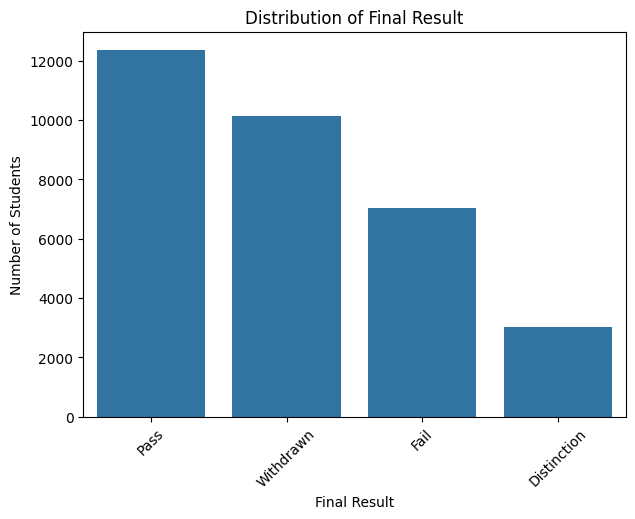

final_result
Pass           12361
Withdrawn      10156
Fail            7052
Distinction     3024
Name: count, dtype: int64
final_result
Pass           37.925321
Withdrawn      31.160065
Fail           21.636548
Distinction     9.278066
Name: proportion, dtype: float64


In [ ]:
### Uni variate analysis of master_25
###Check target results
import matplotlib.pyplot as plt
import seaborn as sns
plt.figure(figsize=(7, 5))

sns.countplot(data=master_25, x='final_result')

plt.title('Distribution of Final Result')
plt.xlabel('Final Result')
plt.ylabel('Number of Students')
plt.xticks(rotation=45)
plt.show()

print(master_25['final_result'].value_counts())
print(master_25['final_result'].value_counts(normalize=True) * 100)

observations: As per our project dropout prediction;
1.Fail students may drop out
2.Withdrawn students 100 % drop out ,but we have to find out early drop out 25% course complete time drop out prediction.


In [ ]:
###Univariate analysis for categorical features
categorical_cols = [
    'code_module',
    'code_presentation',
    'gender',
    'region',
    'highest_education',
    'imd_band',
    'age_band',
    'disability'
]

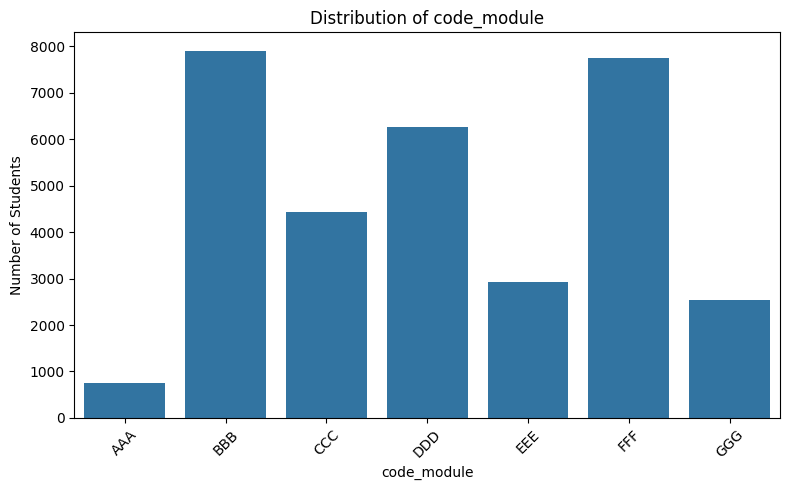


code_module value counts:
code_module
BBB    7909
FFF    7762
DDD    6272
CCC    4434
EEE    2934
GGG    2534
AAA     748
Name: count, dtype: int64


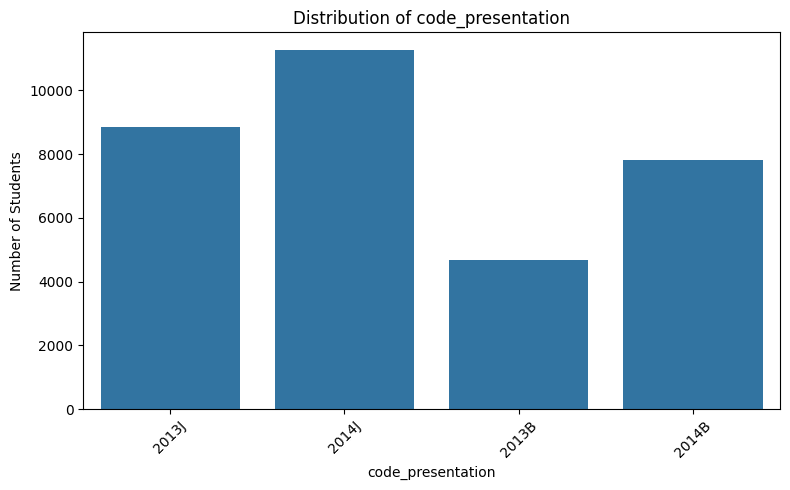


code_presentation value counts:
code_presentation
2014J    11260
2013J     8845
2014B     7804
2013B     4684
Name: count, dtype: int64


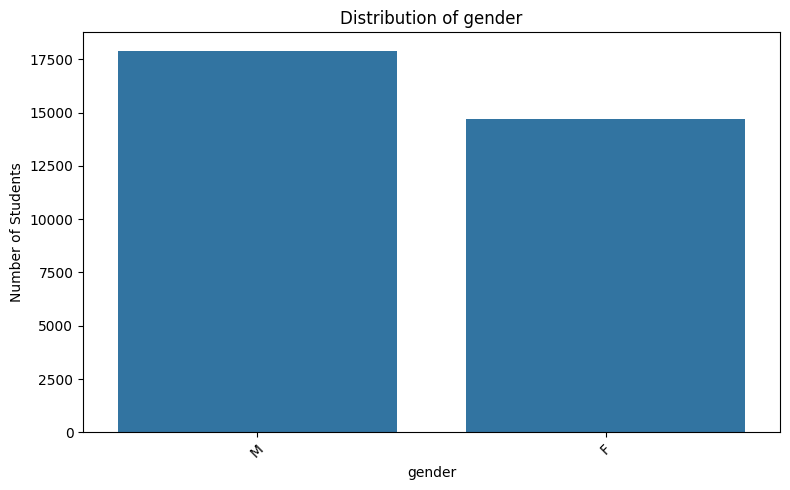


gender value counts:
gender
M    17875
F    14718
Name: count, dtype: int64


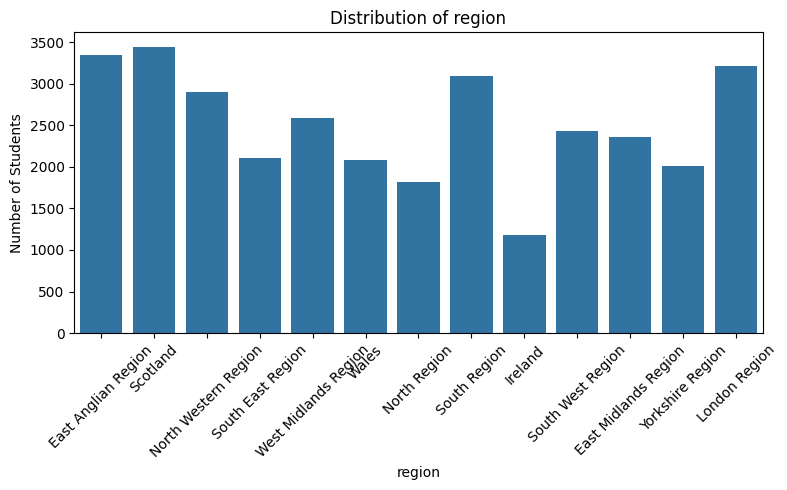


region value counts:
region
Scotland                3446
East Anglian Region     3340
London Region           3216
South Region            3092
North Western Region    2906
West Midlands Region    2582
South West Region       2436
East Midlands Region    2365
South East Region       2111
Wales                   2086
Yorkshire Region        2006
North Region            1823
Ireland                 1184
Name: count, dtype: int64


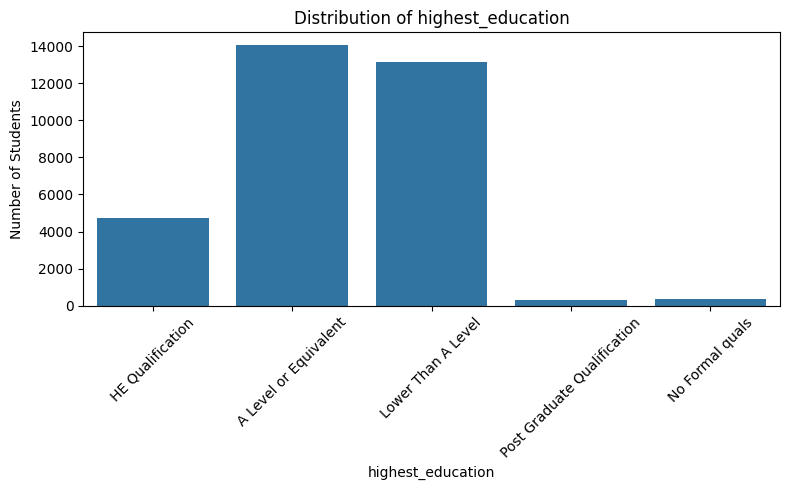


highest_education value counts:
highest_education
A Level or Equivalent          14045
Lower Than A Level             13158
HE Qualification                4730
No Formal quals                  347
Post Graduate Qualification      313
Name: count, dtype: int64


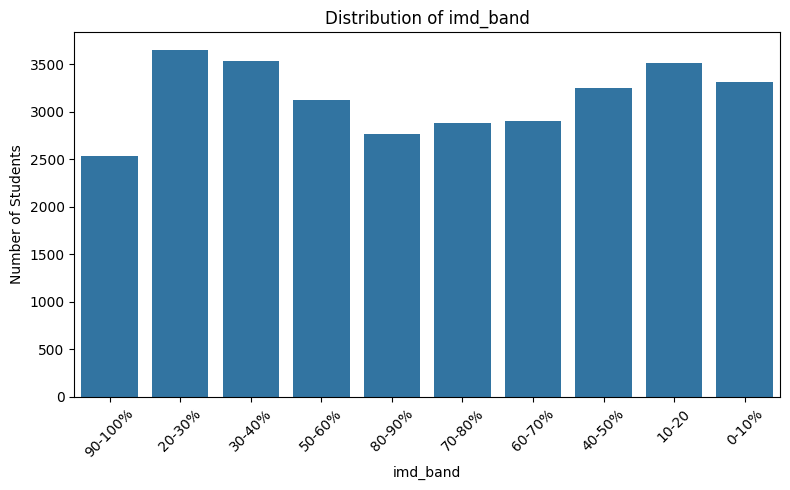


imd_band value counts:
imd_band
20-30%     3654
30-40%     3539
10-20      3516
0-10%      3311
40-50%     3256
50-60%     3124
60-70%     2905
70-80%     2879
80-90%     2762
90-100%    2536
NaN        1111
Name: count, dtype: int64


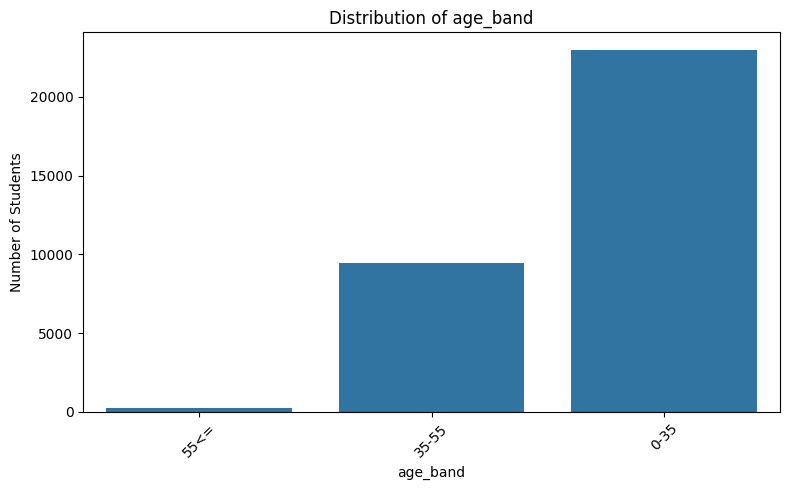


age_band value counts:
age_band
0-35     22944
35-55     9433
55<=       216
Name: count, dtype: int64


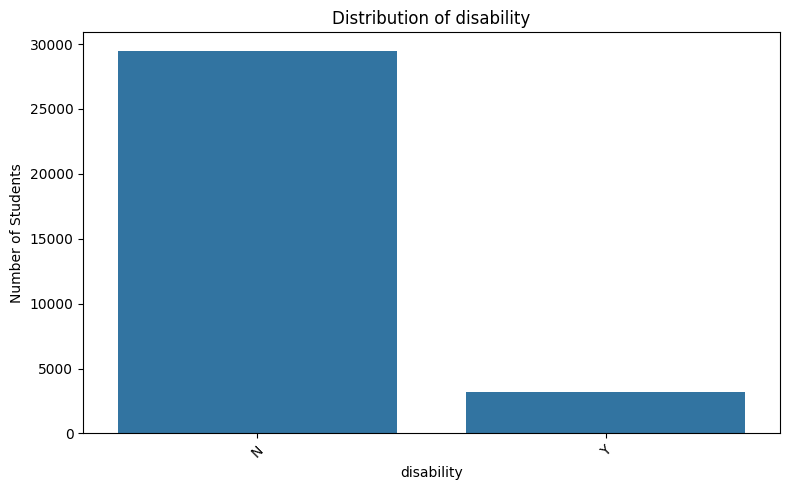


disability value counts:
disability
N    29429
Y     3164
Name: count, dtype: int64


In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(8, 5))
    
    sns.countplot(data=master_25, x=col)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Number of Students')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    print(f"\n{col} value counts:")
    print(master_25[col].value_counts(dropna=False))

In [ ]:
###Univariate analysis EDA for numerical features
numeric_cols = [
    'num_of_prev_attempts',
    'studied_credits',
    'total_assessments',
    'avg_score',
    'max_score',
    'avg_weight',
    'total_weight',
    'avg_submission_date',
    'total_clicks',
    'avg_clicks',
    'max_clicks',
    'active_days'
]

In [ ]:
numeric_cols = [col for col in numeric_cols if col in master_25.columns]

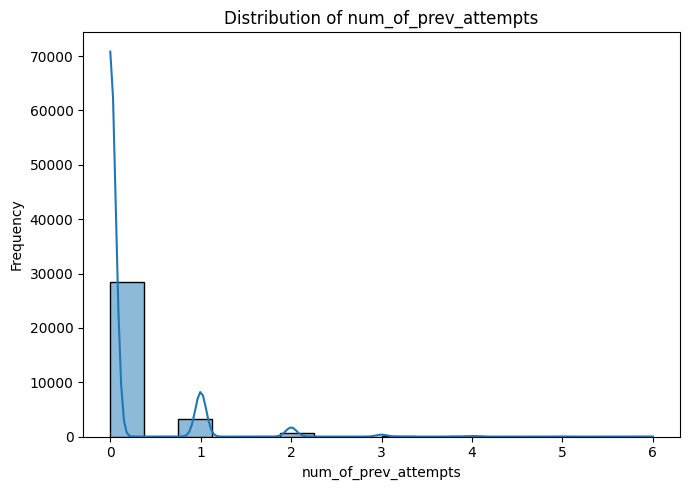

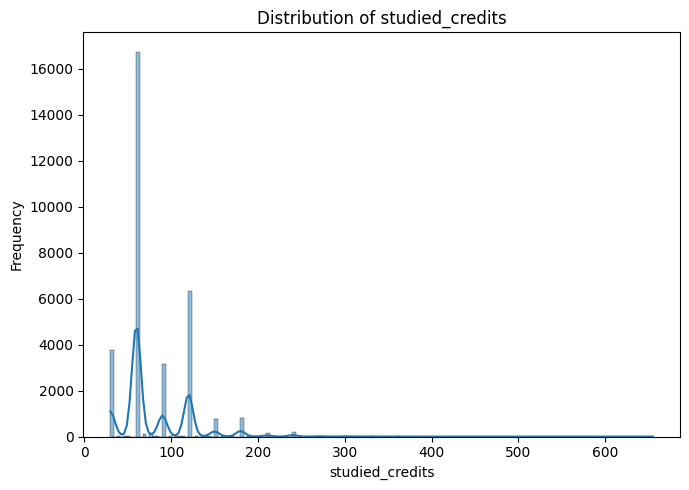

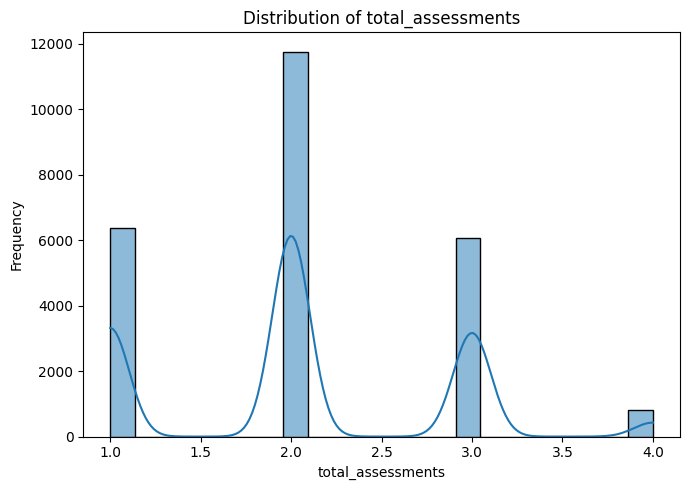

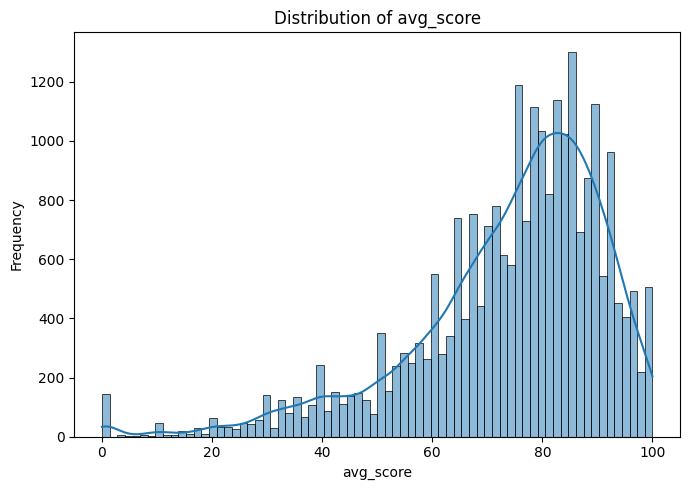

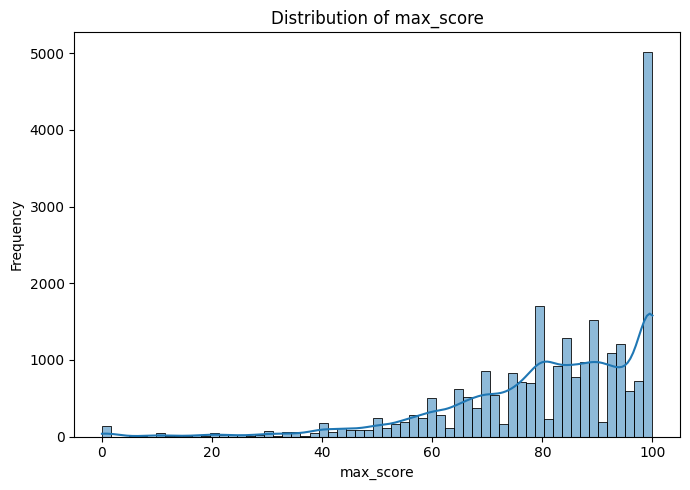

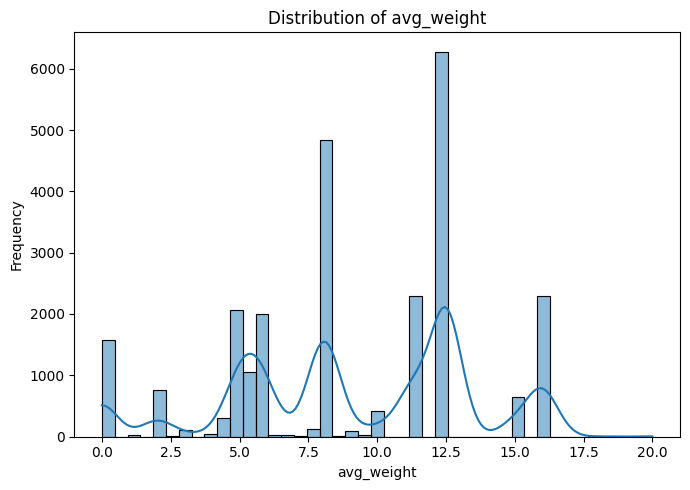

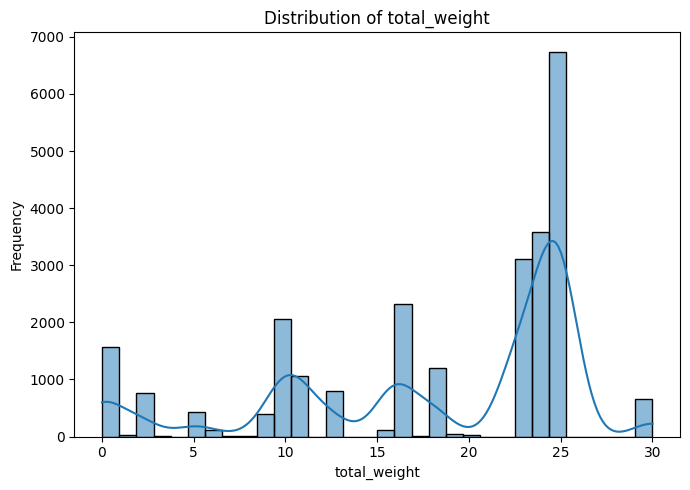

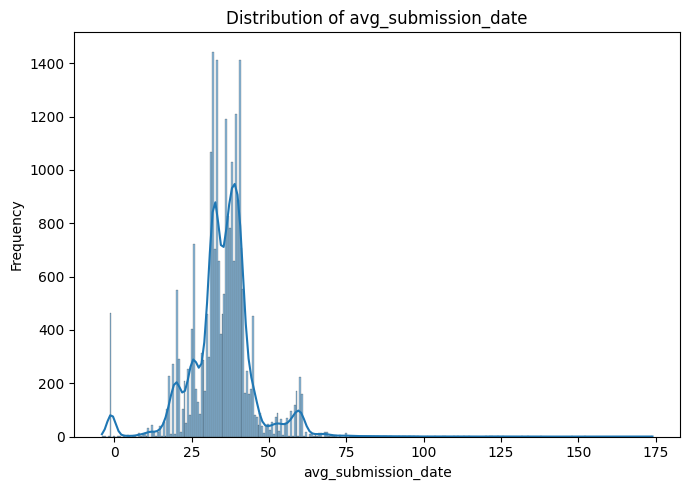

In [ ]:
###Histograms for numerical features
import matplotlib.pyplot as plt
import seaborn as sns
for col in numeric_cols:
    plt.figure(figsize=(7, 5))
    
    sns.histplot(data=master_25, x=col, kde=True)
    
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

###Univariate analysis
1.

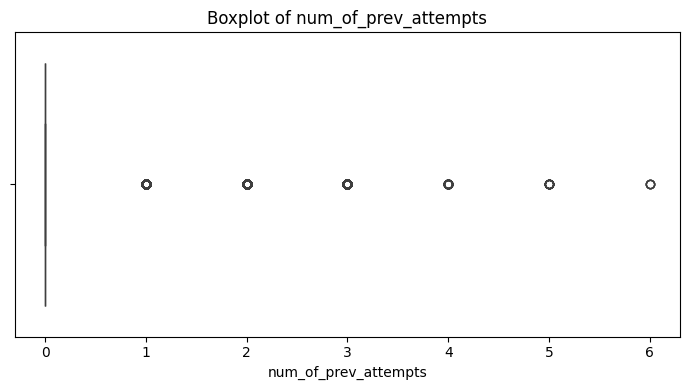

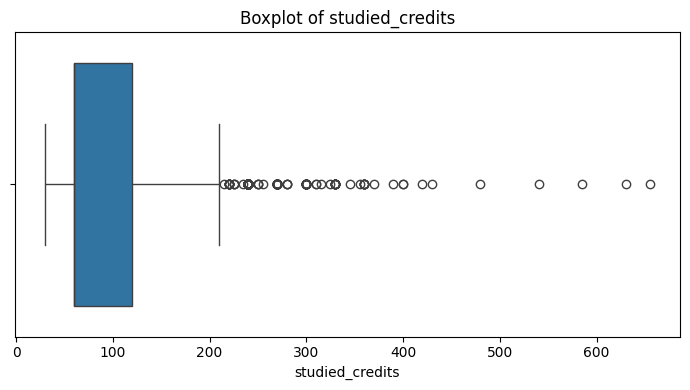

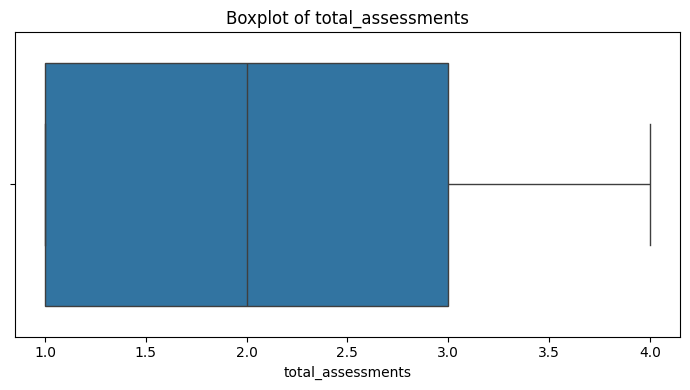

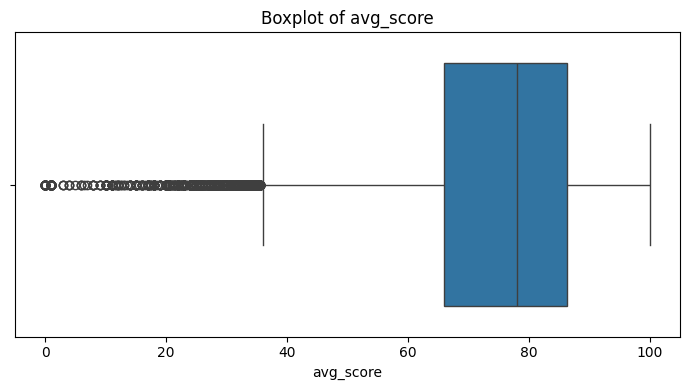

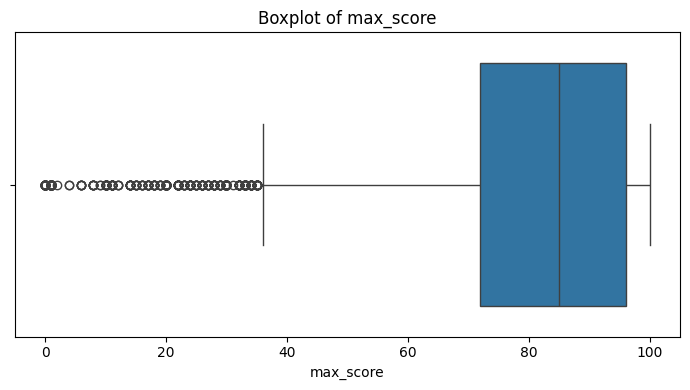

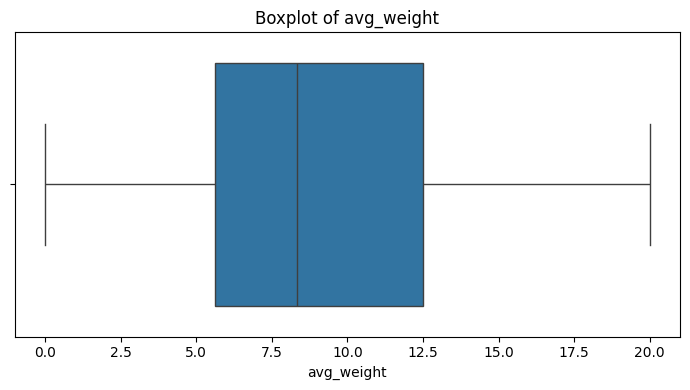

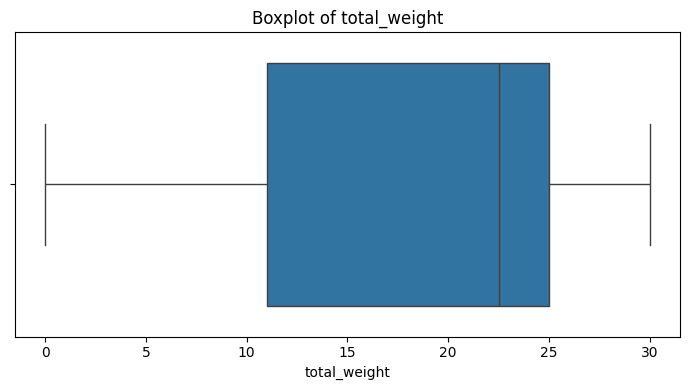

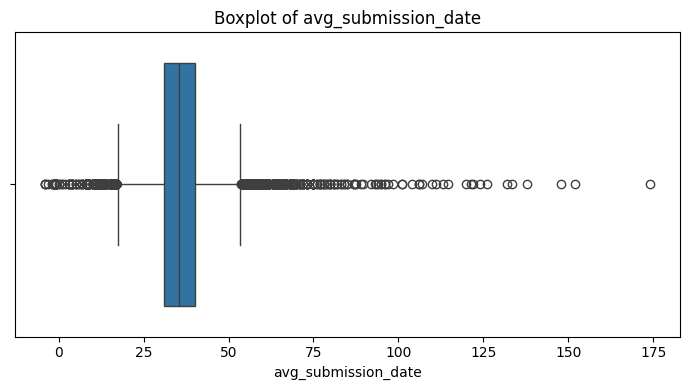

In [ ]:
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(data=master_25, x=col)
    
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

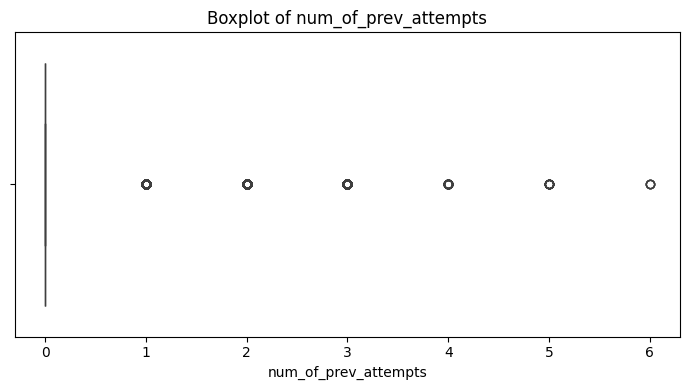

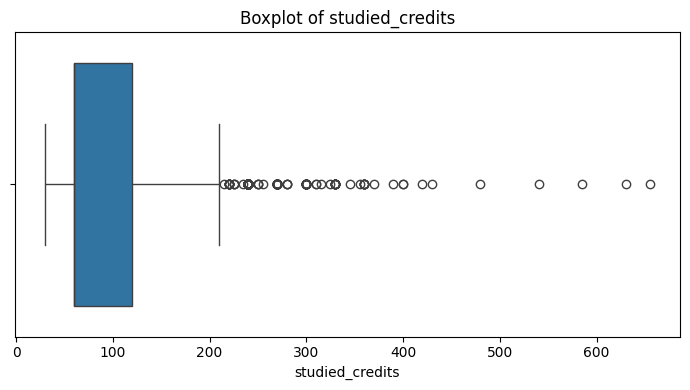

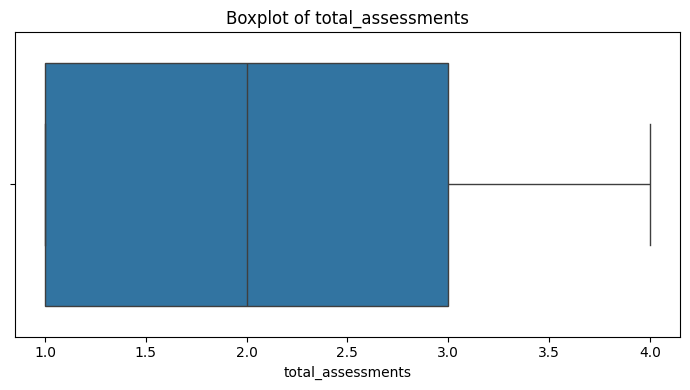

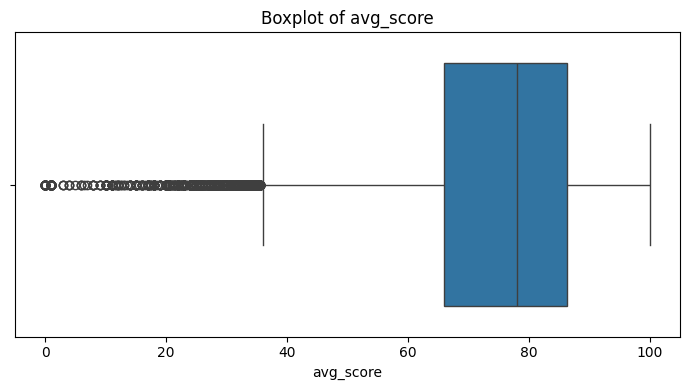

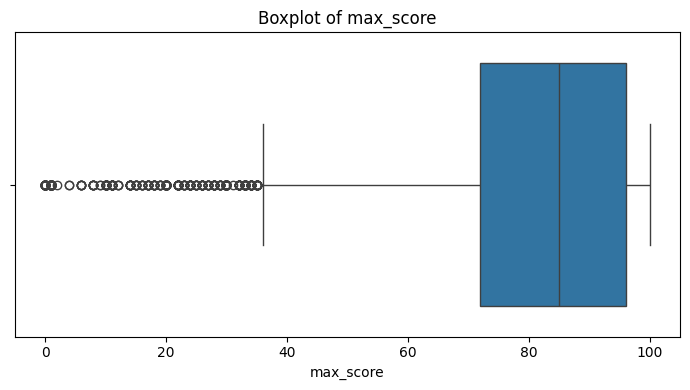

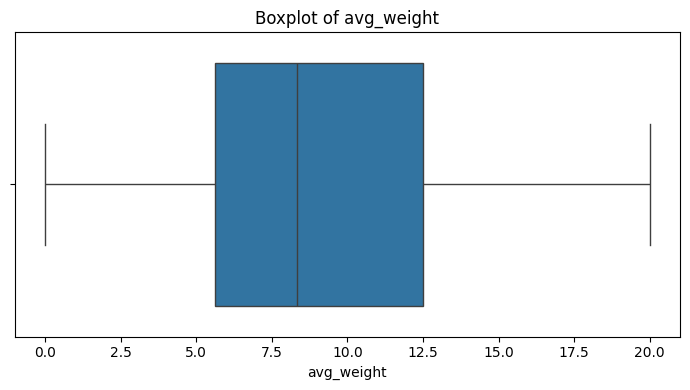

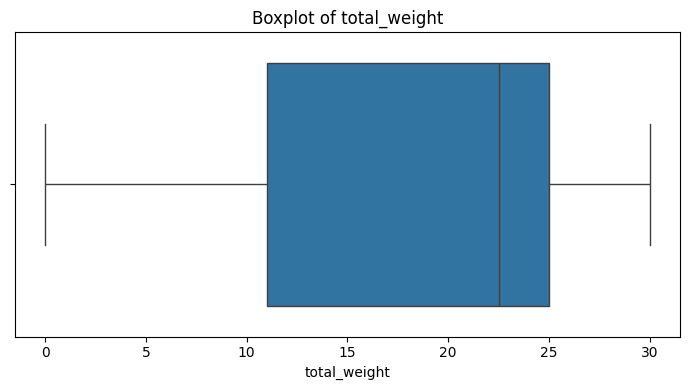

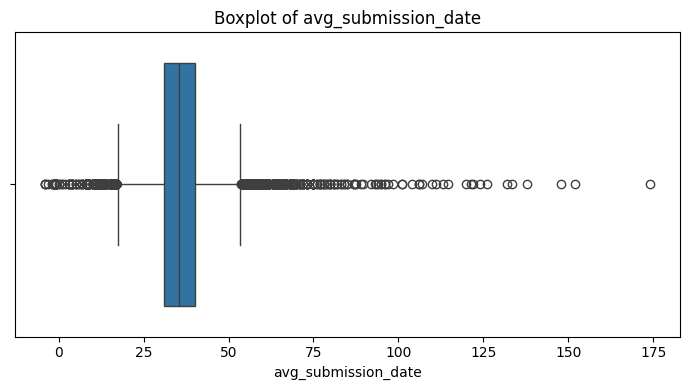

In [ ]:
###Boxplots are importenet to detect outliers in the data.
for col in numeric_cols:
    plt.figure(figsize=(7, 4))
    
    sns.boxplot(data=master_25, x=col)
    
    plt.title(f'Boxplot of {col}')
    plt.xlabel(col)
    plt.tight_layout()
    plt.show()

In [ ]:
master_25[numeric_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_of_prev_attempts,32593.0,0.163225,0.479758,0.0,0.000,0.000000,0.000000,6.0
studied_credits,32593.0,79.758691,41.071900,30.0,60.000,60.000000,120.000000,655.0
total_assessments,25023.0,2.053870,0.790585,1.0,1.000,2.000000,3.000000,4.0
avg_score,25023.0,74.042724,17.614311,0.0,66.000,78.000000,86.333333,100.0
max_score,25023.0,81.398593,17.806045,0.0,72.000,85.000000,96.000000,100.0
avg_weight,25023.0,9.106389,4.356325,0.0,5.625,8.333333,12.500000,20.0
total_weight,25023.0,18.235383,8.169066,0.0,11.000,22.500000,25.000000,30.0
avg_submission_date,25023.0,34.922651,10.615972,-4.0,31.000,35.500000,40.000000,174.0


In [ ]:
master_25.isnull().sum().sort_values(ascending=False)

module_presentation_length    32205
sum_click                     32205
id_site                       32205
cutoff_25                     32205
date                          32205
avg_score                      7570
total_assessments              7570
avg_weight                     7570
avg_submission_date            7570
total_weight                   7570
max_score                      7570
imd_band                       1111
code_presentation                 0
code_module                       0
id_student                        0
highest_education                 0
region                            0
gender                            0
final_result                      0
age_band                          0
num_of_prev_attempts              0
studied_credits                   0
disability                        0
dtype: int64

###fill missing values with 

In [ ]:
####save master_25 to csv
master_25.to_csv('master_25.csv', index=False)

In [ ]:
import csv
from pathlib import Path

# Change this only if your CSV files are in a different folder.
DATA_FOLDER = Path(".")

INPUT = DATA_FOLDER / "master_25.csv"
COURSES = DATA_FOLDER / "courses.csv"
OUTPUT = DATA_FOLDER / "master_25_filled.csv"


def is_missing(value):
    """Identify blank and common missing-value markers."""
    return value is None or value.strip().lower() in {"", "na", "nan", "null"}


# Load module-presentation durations from OULAD courses.csv
course_lengths = {}

with COURSES.open(newline="", encoding="utf-8-sig") as file:
    for course in csv.DictReader(file):
        key = (course["code_module"], course["code_presentation"])
        course_lengths[key] = course["module_presentation_length"]


# Read master_25.csv, fill missing values, and write a new CSV
with INPUT.open(newline="", encoding="utf-8-sig") as infile, \
     OUTPUT.open("w", newline="", encoding="utf-8") as outfile:

    reader = csv.DictReader(infile)
    writer = csv.DictWriter(outfile, fieldnames=reader.fieldnames)
    writer.writeheader()

    for row in reader:

        # OULAD has no known IMD value for these students.
        if is_missing(row["imd_band"]):
            row["imd_band"] = "Unknown"

        # No assessment activity observed by the 25% completion checkpoint.
        assessment_columns = [
            "total_assessments",
            "avg_score",
            "max_score",
            "avg_weight",
            "total_weight",
            "avg_submission_date",
        ]

        for column in assessment_columns:
            if is_missing(row[column]):
                row[column] = "0.0"

        # No VLE activity observed by the 25% completion checkpoint.
        vle_columns = ["id_site", "date", "sum_click"]

        for column in vle_columns:
            if is_missing(row[column]):
                row[column] = "0.0"

        # Restore course-level values from courses.csv.
        course_key = (row["code_module"], row["code_presentation"])
        module_length = course_lengths[course_key]

        if is_missing(row["module_presentation_length"]):
            row["module_presentation_length"] = module_length

        if is_missing(row["cutoff_25"]):
            row["cutoff_25"] = str(float(module_length) * 0.25)

        writer.writerow(row)

print(f"Done. Filled dataset saved as: {OUTPUT.resolve()}")

Done. Filled dataset saved as: /Users/perecharlaprasad/Downloads/archive/master_25_filled.csv


In [ ]:
import pandas as pd
master_25_filled = pd.read_csv(OUTPUT)

In [ ]:
master_25_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    32593 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  total_assessments           32593 non-null  float64
 13  avg_score                   325

In [ ]:
master_25_filled.isnull().sum().sort_values(ascending=False)    

code_module                   0
code_presentation             0
id_student                    0
gender                        0
region                        0
highest_education             0
imd_band                      0
age_band                      0
num_of_prev_attempts          0
studied_credits               0
disability                    0
final_result                  0
total_assessments             0
avg_score                     0
max_score                     0
avg_weight                    0
total_weight                  0
avg_submission_date           0
id_site                       0
date                          0
sum_click                     0
module_presentation_length    0
cutoff_25                     0
dtype: int64

master_25 dataset missing values replaced and renamed master_25_filled.

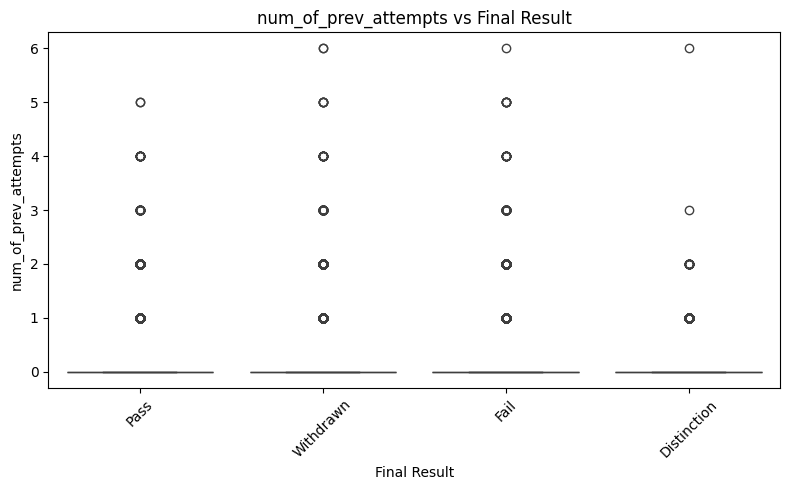

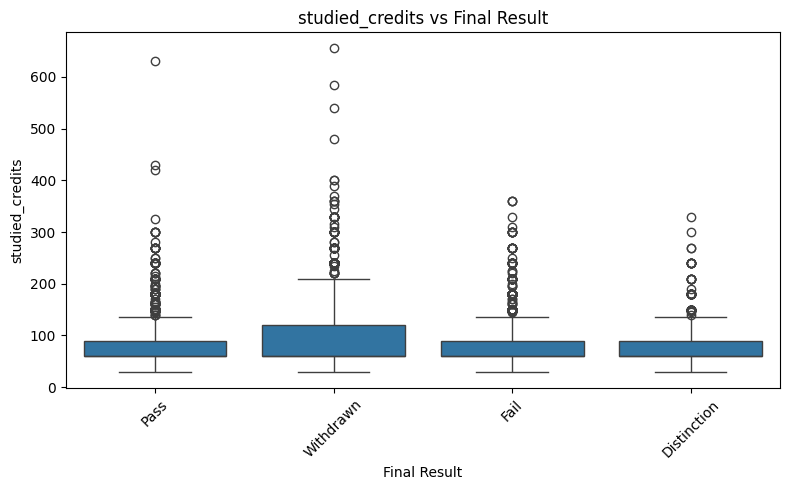

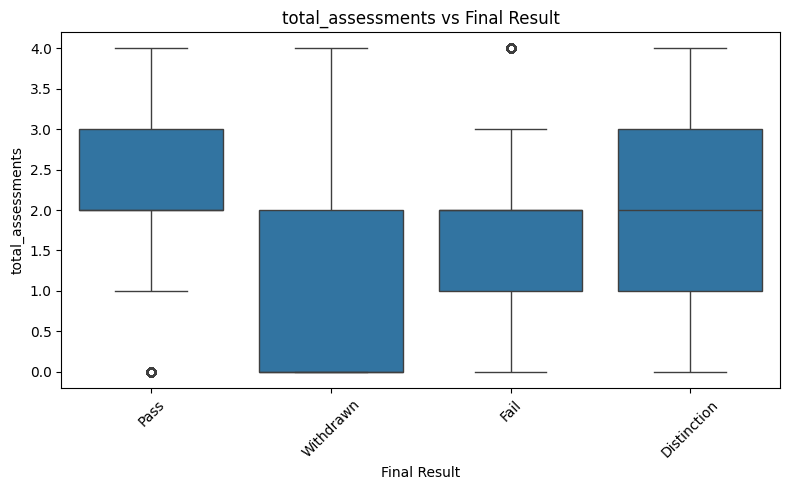

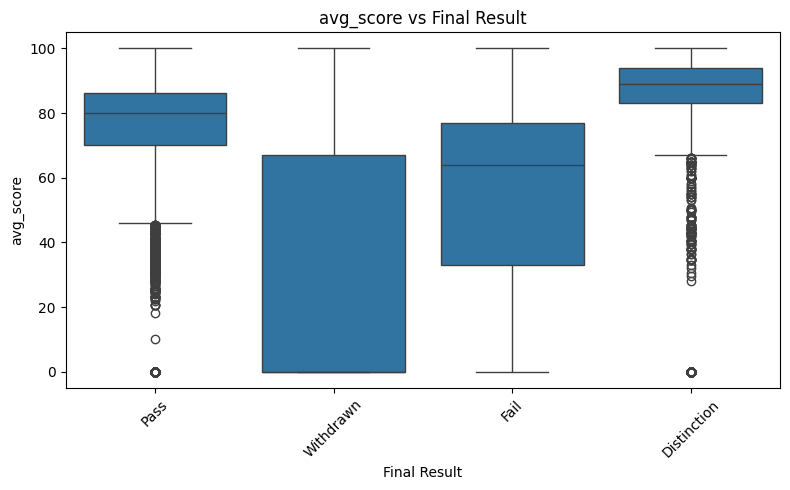

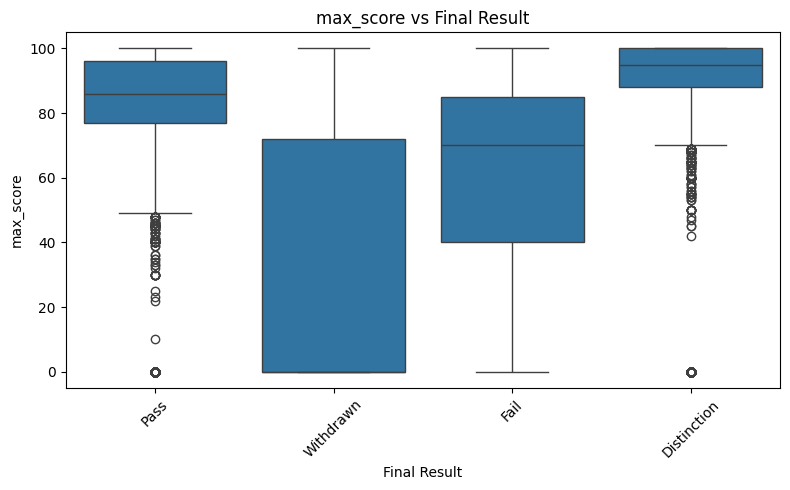

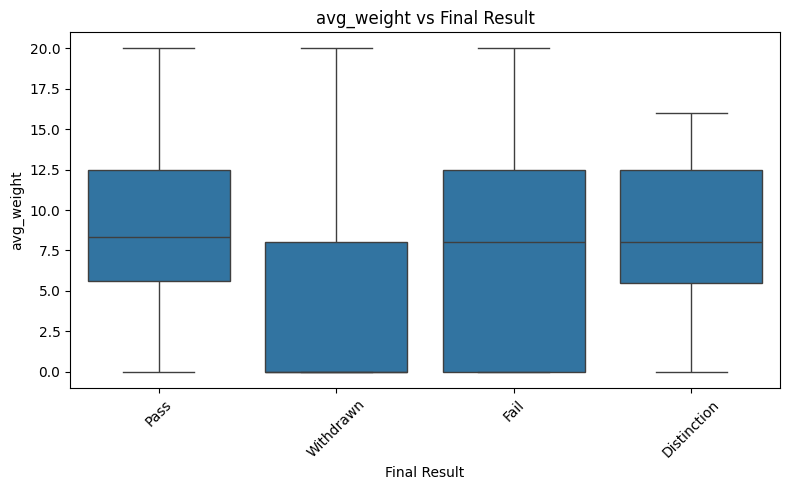

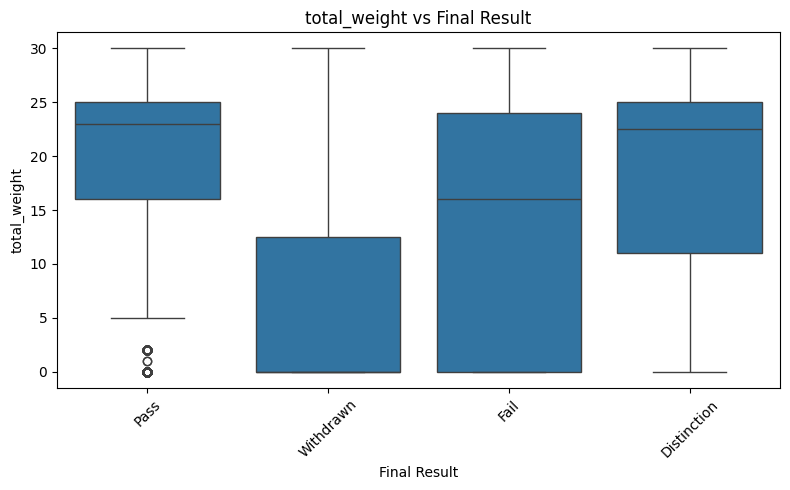

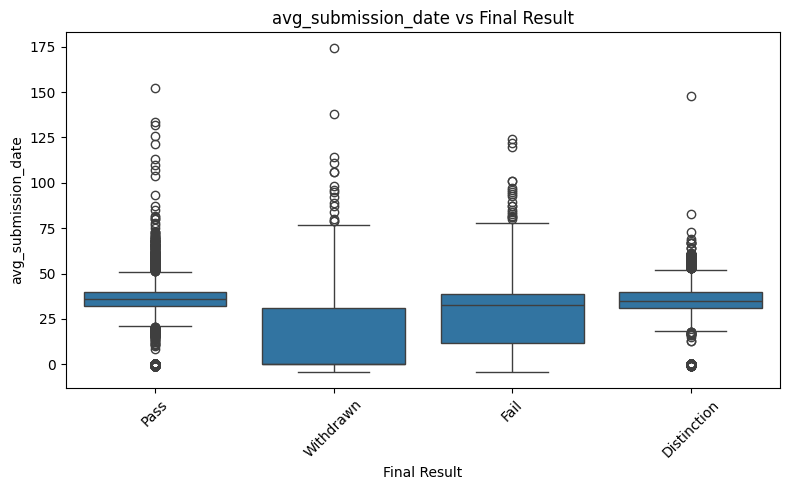

In [ ]:
###bivariate EDA-Numerical vs dropout outcome
for col in numeric_cols:
    plt.figure(figsize=(8, 5))
    
    sns.boxplot(
        data=master_25_filled,
        x='final_result',
        y=col
    )
    
    plt.title(f'{col} vs Final Result')
    plt.xlabel('Final Result')
    plt.ylabel(col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

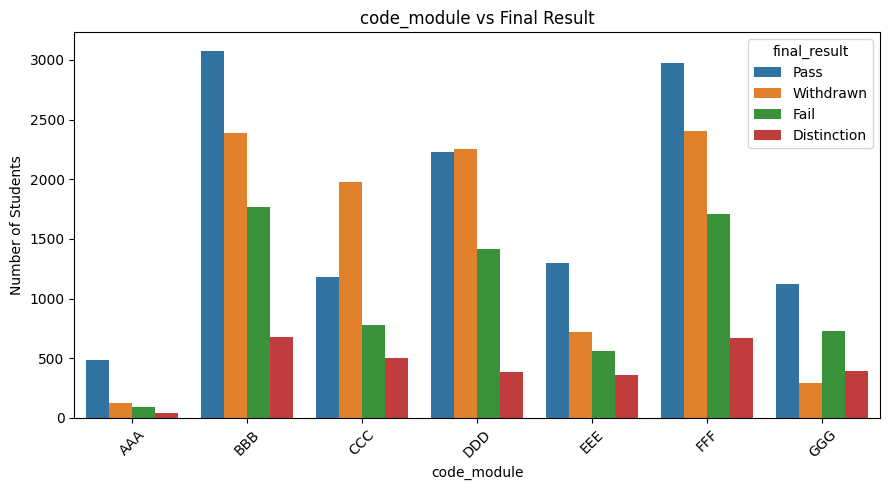

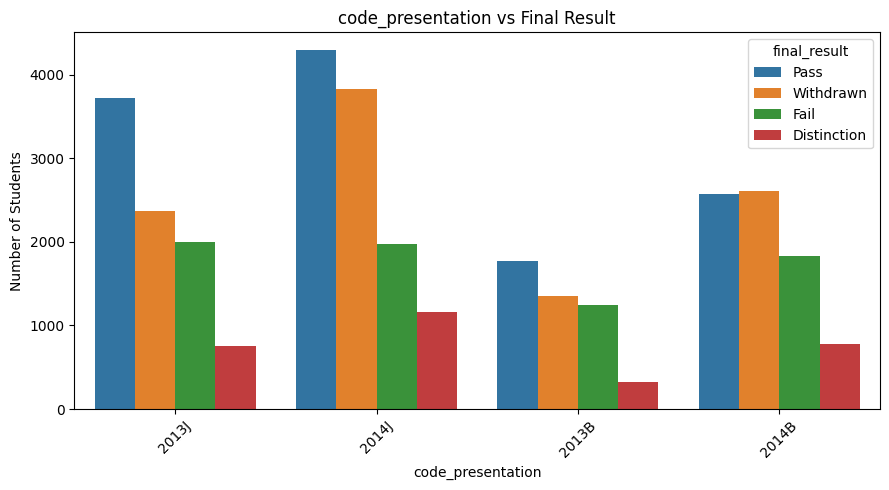

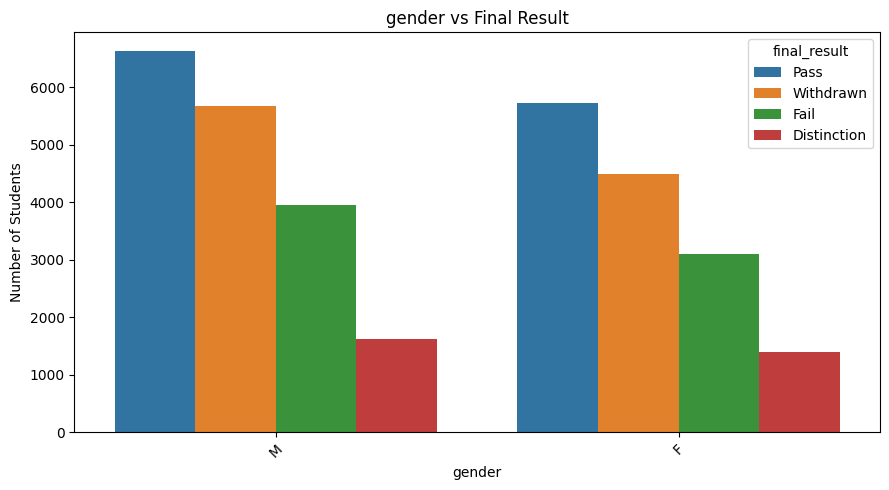

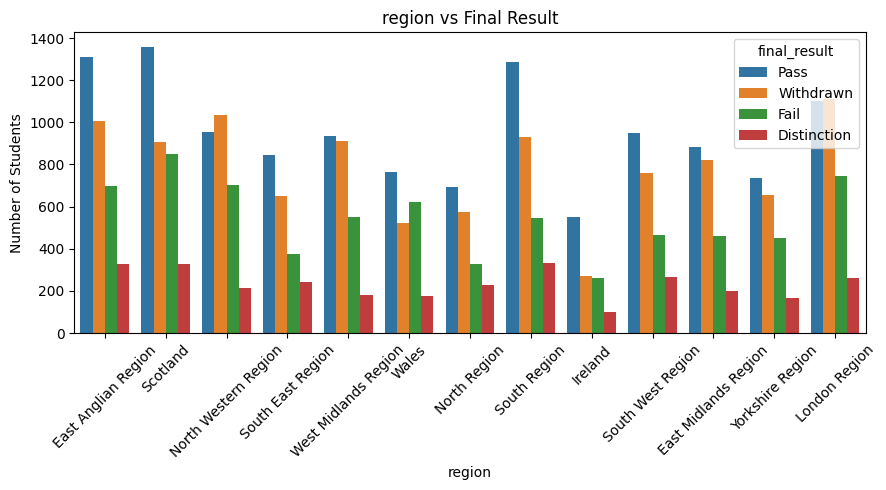

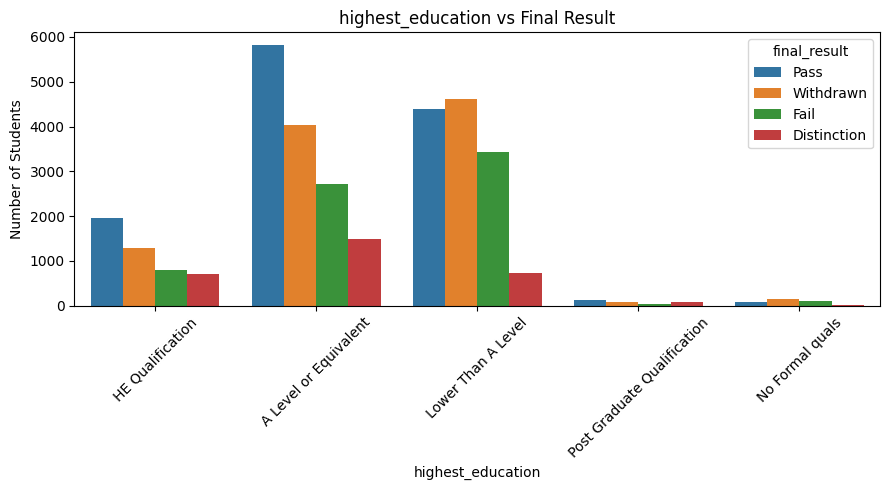

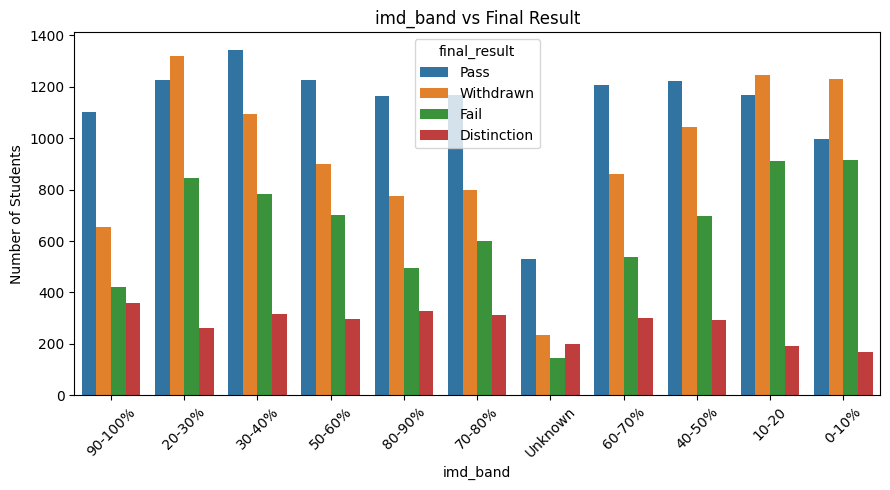

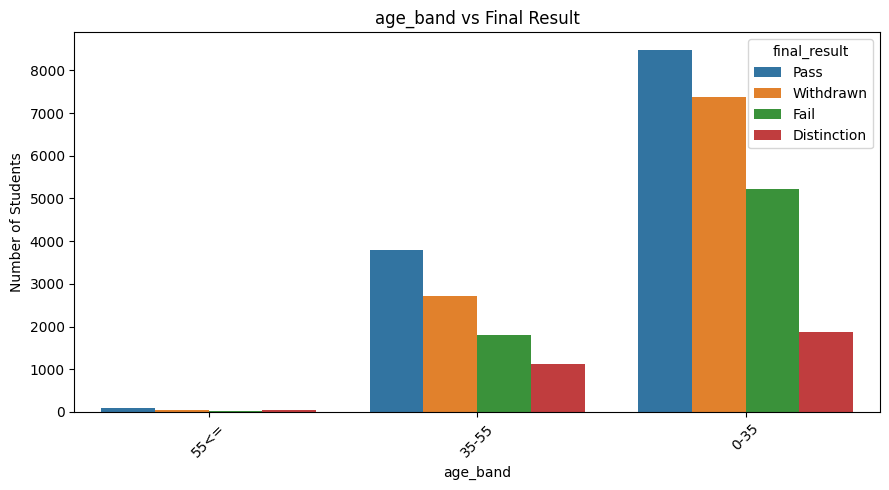

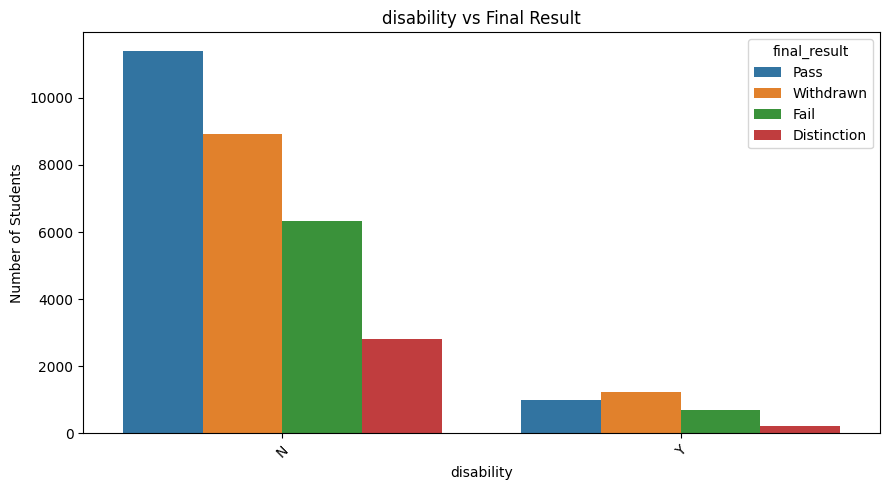

In [ ]:
for col in categorical_cols:
    plt.figure(figsize=(9, 5))
    
    sns.countplot(
        data=master_25_filled,
        x=col,
        hue='final_result'
    )
    
    plt.title(f'{col} vs Final Result')
    plt.xlabel(col)
    plt.ylabel('Number of Students')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [ ]:
###Bivariate analysis using  percentage,
for col in categorical_cols:
    
    temp = pd.crosstab(
        master_25_filled[col],
        master_25_filled['final_result'],
        normalize='index'
    ) * 100
    
    print(f"\nPercentage distribution: {col}")
    display(temp.round(2))


Percentage distribution: code_module


final_result,Distinction,Fail,Pass,Withdrawn
code_module,,,,
AAA,5.88,12.17,65.11,16.84
BBB,8.56,22.34,38.91,30.19
CCC,11.23,17.61,26.61,44.54
DDD,6.11,22.51,35.51,35.87
EEE,12.13,19.15,44.10,24.61
FFF,8.63,22.04,38.37,30.96
GGG,15.63,28.73,44.12,11.52



Percentage distribution: code_presentation


final_result,Distinction,Fail,Pass,Withdrawn
code_presentation,,,,
2013B,6.98,26.49,37.75,28.78
2013J,8.47,22.62,42.13,26.78
2014B,10.05,23.49,32.98,33.48
2014J,10.34,17.56,38.13,33.98



Percentage distribution: gender


...

final_result,Distinction,Fail,Pass,Withdrawn
imd_band,,,,
0-10%,5.07,27.67,30.08,37.18
10-20,5.43,25.94,33.19,35.44
20-30%,7.20,23.10,33.55,36.15
30-40%,8.90,22.15,38.01,30.94
40-50%,9.00,21.41,37.59,32.00
50-60%,9.51,22.44,39.28,28.78
60-70%,10.29,18.52,41.62,29.57
70-80%,10.87,20.81,40.64,27.68
80-90%,11.88,17.92,42.18,28.02



Percentage distribution: age_band


final_result,Distinction,Fail,Pass,Withdrawn
age_band,,,,
0-35,8.12,22.80,36.91,32.17
35-55,11.87,19.00,40.28,28.85
55<=,18.98,13.43,42.59,25.00



Percentage distribution: disability


final_result,Distinction,Fail,Pass,Withdrawn
disability,,,,
N,9.52,21.54,38.66,30.28
Y,7.05,22.50,31.10,39.35


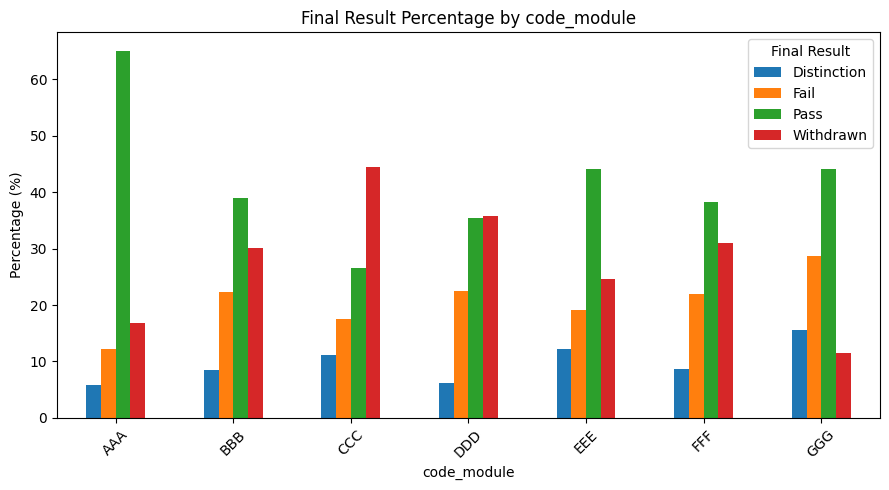

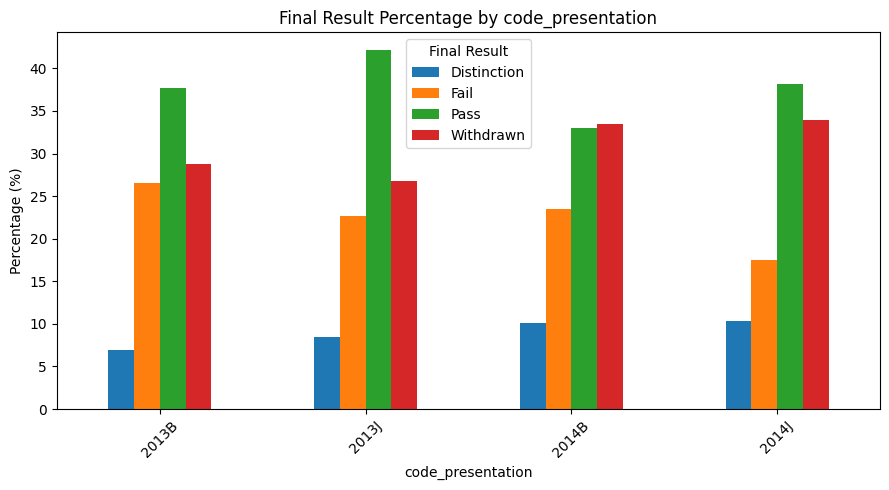

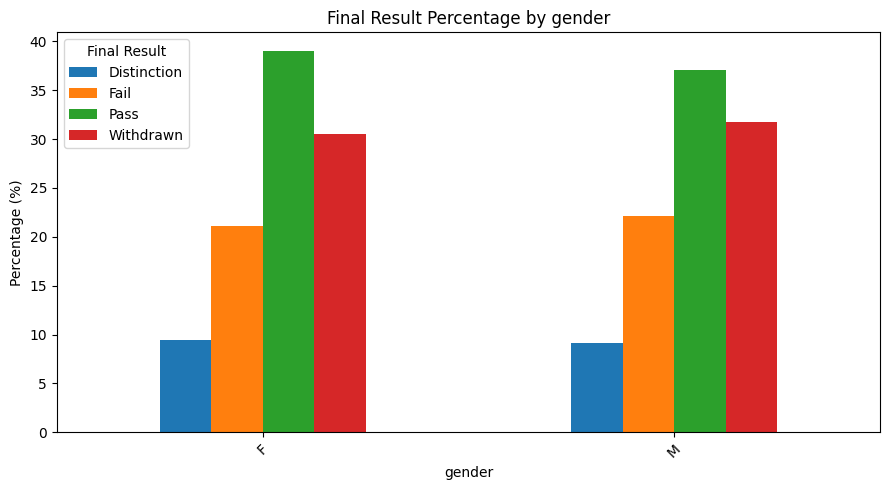

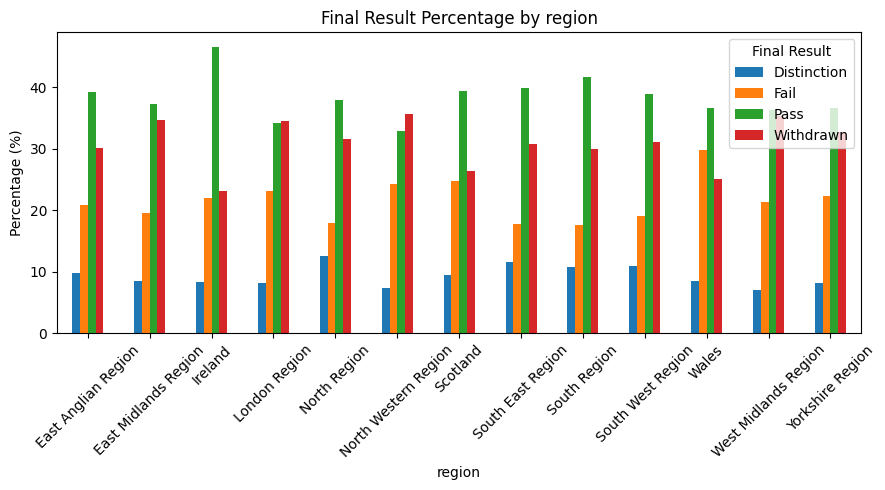

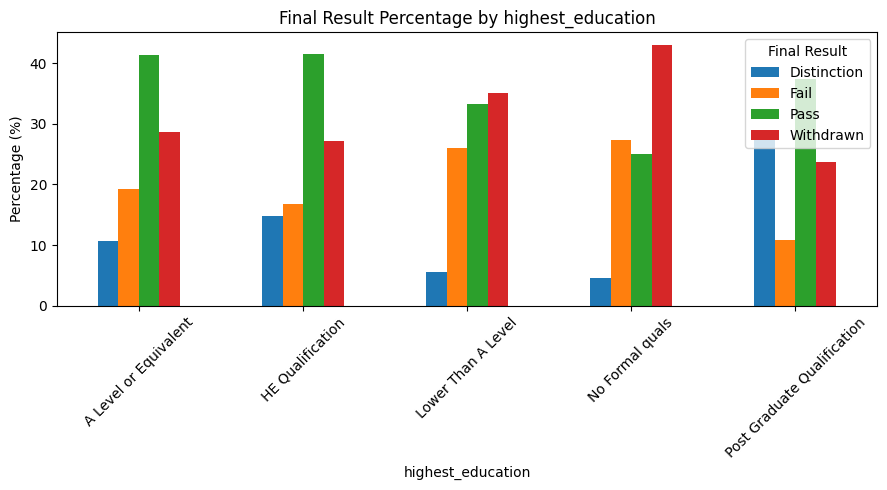

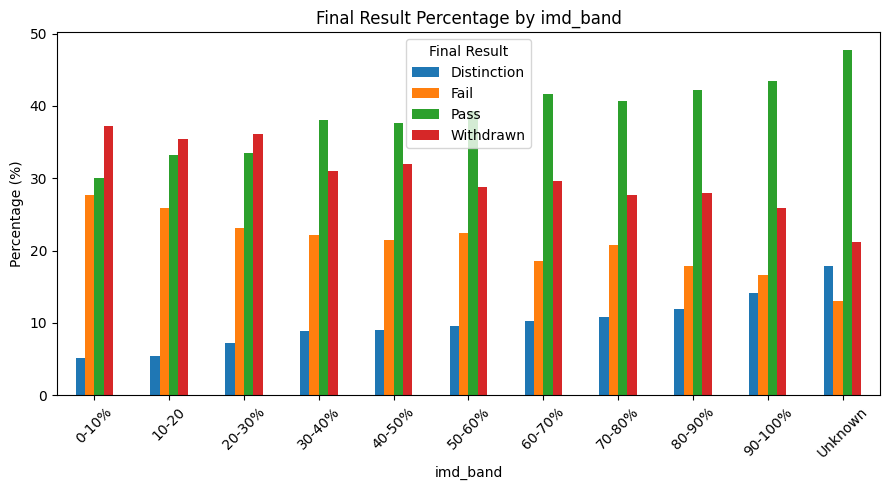

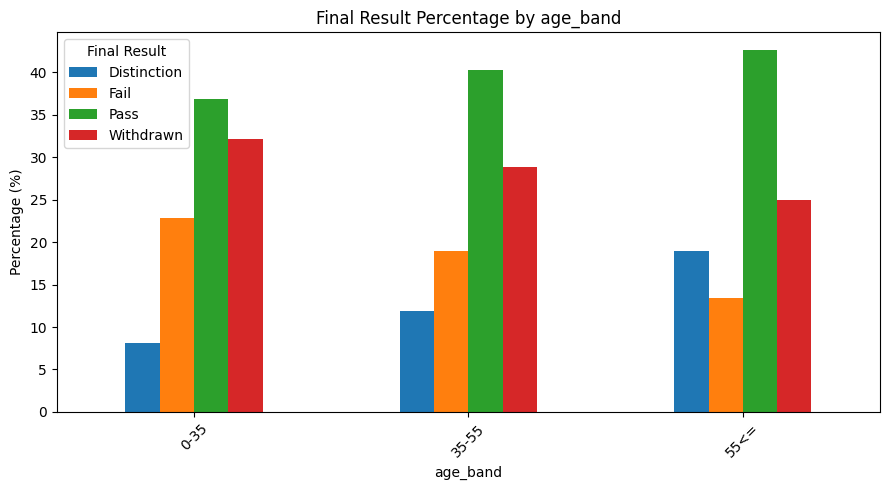

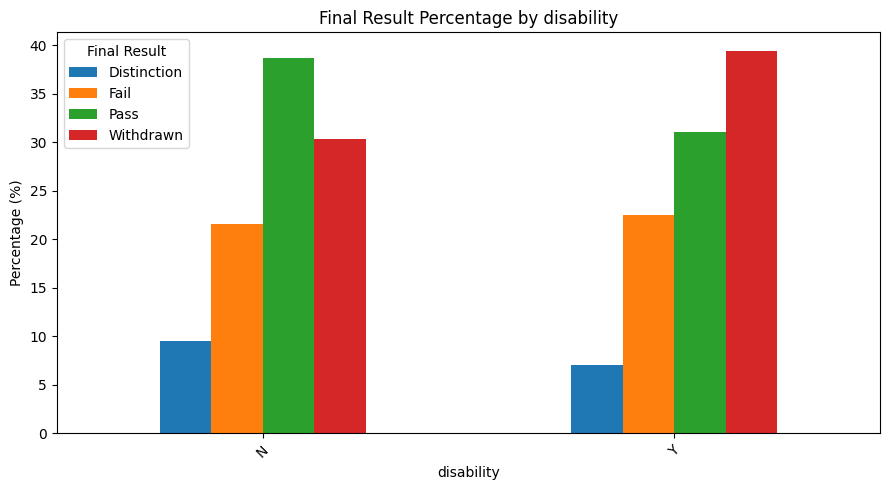

In [ ]:
###Plot percentage distribution
for col in categorical_cols:
    
    temp = pd.crosstab(
        master_25_filled[col],
        master_25_filled['final_result'],
        normalize='index'
    ) * 100
    
    temp.plot(
        kind='bar',
        figsize=(9, 5)
    )
    
    plt.title(f'Final Result Percentage by {col}')
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=45)
    plt.legend(title='Final Result')
    plt.tight_layout()
    plt.show()

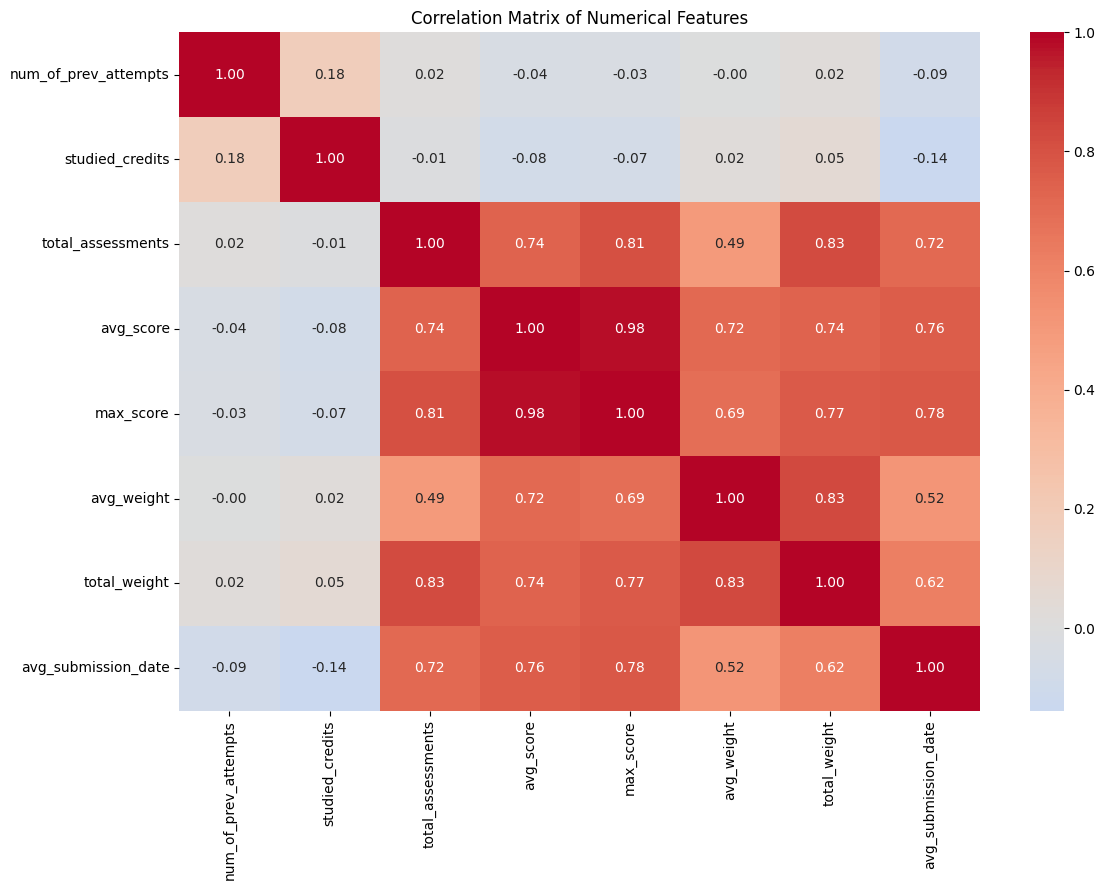

In [ ]:
###Correlation analysis for numerical variables
plt.figure(figsize=(12, 9))

corr = master_25_filled[numeric_cols].corr()

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()

In [ ]:
###Correlation with encoded target
master_25_filled['target_encoded'] = master_25_filled['final_result'].map({
    'Withdrawn': 1,
    'Fail': 1,
    'Pass': 0,
    'Distinction': 0
})

In [ ]:
### Correlation with encoded target

# Select all numeric columns
numeric_cols = master_25_filled.select_dtypes(include='number').columns.tolist()

# Remove target from feature list
if 'target_encoded' in numeric_cols:
    numeric_cols.remove('target_encoded')

# Calculate correlation with target
target_corr = (
    master_25_filled[numeric_cols + ['target_encoded']]
    .corr()['target_encoded']
    .drop('target_encoded')
    .sort_values(ascending=False)
)

print(target_corr)

studied_credits               0.138630
num_of_prev_attempts          0.105460
date                         -0.011171
id_student                   -0.020442
sum_click                    -0.042521
cutoff_25                    -0.055734
module_presentation_length   -0.055734
id_site                      -0.056806
avg_weight                   -0.364577
total_assessments            -0.421935
total_weight                 -0.428853
avg_submission_date          -0.447859
max_score                    -0.536283
avg_score                    -0.537567
Name: target_encoded, dtype: float64


In [ ]:
####Correlation with encoded target
target_corr = (
    master_25_filled[numeric_cols + ['target_encoded']]
    .corr()['target_encoded']
    .sort_values(ascending=False)
)

print(target_corr)

target_encoded                1.000000
studied_credits               0.138630
num_of_prev_attempts          0.105460
date                         -0.011171
id_student                   -0.020442
sum_click                    -0.042521
module_presentation_length   -0.055734
cutoff_25                    -0.055734
id_site                      -0.056806
avg_weight                   -0.364577
total_assessments            -0.421935
total_weight                 -0.428853
avg_submission_date          -0.447859
max_score                    -0.536283
avg_score                    -0.537567
Name: target_encoded, dtype: float64


In [ ]:
master_25_filled['target_dropout'] = (
    master_25_filled['final_result'] == 'Withdrawn'
).astype(int)

In [ ]:
print(master_25_filled['target_dropout'].value_counts())
print(
    master_25_filled['target_dropout']
    .value_counts(normalize=True) * 100
)

target_dropout
0    22437
1    10156
Name: count, dtype: int64
target_dropout
0    68.839935
1    31.160065
Name: proportion, dtype: float64


In [ ]:
master_25_filled.head()

,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,avg_weight,total_weight,avg_submission_date,id_site,date,sum_click,module_presentation_length,cutoff_25,target_encoded,target_dropout
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,15.0,30.0,35.5,546652.0,0.0,5.0,268.0,67.0,0,0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,15.0,30.0,37.0,546657.0,0.0,4.0,268.0,67.0,0,0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,0.0,0.0,0.0,546652.0,4.0,2.0,268.0,67.0,1,1
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,15.0,30.0,34.0,546614.0,1.0,5.0,268.0,67.0,0,0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,15.0,30.0,50.5,546652.0,1.0,5.0,268.0,67.0,0,0


In [ ]:
###save master_25_filled to csv
master_25_filled.to_csv('master_25_filled.csv', index=False)

In [ ]:
master_25_filled.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32593 entries, 0 to 32592
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   code_module                 32593 non-null  object 
 1   code_presentation           32593 non-null  object 
 2   id_student                  32593 non-null  int64  
 3   gender                      32593 non-null  object 
 4   region                      32593 non-null  object 
 5   highest_education           32593 non-null  object 
 6   imd_band                    32593 non-null  object 
 7   age_band                    32593 non-null  object 
 8   num_of_prev_attempts        32593 non-null  int64  
 9   studied_credits             32593 non-null  int64  
 10  disability                  32593 non-null  object 
 11  final_result                32593 non-null  object 
 12  total_assessments           32593 non-null  float64
 13  avg_score                   325

###Feature engineering

In [ ]:
"""Feature engineering for master_25_filled.csv.

The output retains label columns for evaluation but excludes them from FEATURES.
"""

# %% Imports and input
from pathlib import Path

import numpy as np
import pandas as pd

INPUT_FILE = Path("master_25_filled.csv")
OUTPUT_FILE = Path("master_25_filled_featured.csv")

df = pd.read_csv(INPUT_FILE)

# %% Feature engineering
EPSILON = 1e-6

# Course duration and engagement timing.
df["course_progress_at_activity"] = (df["date"] / df["module_presentation_length"].clip(lower=1)).clip(0, 1)
df["days_remaining_in_course"] = (df["module_presentation_length"] - df["date"]).clip(lower=0)
df["activity_in_first_quarter"] = (df["course_progress_at_activity"] <= 0.25).astype("int8")

# Assessment participation and performance. Zero-assessment cases are kept as zero.
df["assessment_completion_rate"] = df["total_assessments"] / df.groupby(
    ["code_module", "code_presentation"]
)["total_assessments"].transform("max").clip(lower=1)
df["score_range"] = (df["max_score"] - df["avg_score"]).clip(lower=0)
df["score_to_cutoff_gap"] = df["avg_score"] - df["cutoff_25"]
df["score_above_cutoff"] = (df["avg_score"] >= df["cutoff_25"]).astype("int8")
df["weighted_score_proxy"] = df["avg_score"] * df["total_weight"]
df["submission_delay_ratio"] = df["avg_submission_date"] / df["module_presentation_length"].clip(lower=1)
df["has_assessment_submission"] = (df["total_assessments"] > 0).astype("int8")

# VLE engagement intensity. log_sum_click exists in the source, but these add
# interpretable scale- and course-normalised measures.
df["clicks_per_course_day"] = df["sum_click"] / df["module_presentation_length"].clip(lower=1)
df["clicks_per_active_day_safe"] = df["sum_click"] / df["date"].clip(lower=1)
df["engagement_density"] = df["sum_click"] / (df["date"] + 1)
df["high_engagement"] = (df["sum_click"] >= df.groupby(
    ["code_module", "code_presentation"]
)["sum_click"].transform("median")).astype("int8")

# Workload and prior-experience features.
df["credits_per_previous_attempt"] = df["studied_credits"] / (df["num_of_prev_attempts"] + 1)
df["is_high_credit_load"] = (df["studied_credits"] >= 120).astype("int8")
df["has_previous_attempt"] = (df["num_of_prev_attempts"] > 0).astype("int8")

# Ordered socio-demographic versions of categorical bands. Keep the original
# categorical columns too: one-hot encoding them can preserve non-linear effects.
imd_map = {
    "0-10%": 5, "10-20%": 15, "10-20": 15, "20-30%": 25, "30-40%": 35, "40-50%": 45,
    "50-60%": 55, "60-70%": 65, "70-80%": 75, "80-90%": 85, "90-100%": 95,
    "Unknown": -1,
}
age_map = {"0-35": 25, "35-55": 45, "55<=": 60}
education_map = {
    "No Formal quals": 0, "Lower Than A Level": 1, "A Level or Equivalent": 2,
    "HE Qualification": 3, "Post Graduate Qualification": 4,
}
df["imd_percentile_midpoint"] = df["imd_band"].map(imd_map)
df["age_band_midpoint"] = df["age_band"].map(age_map)
df["education_level_ordinal"] = df["highest_education"].map(education_map)

# Identifiers should not be numeric model features. Retain id_student for joining
# and convert id_site to a categorical value rather than implying numeric order.
df["id_site"] = df["id_site"].astype("Int64").astype("string")

# %% Save engineered data
df.to_csv(OUTPUT_FILE, index=False)
print(f"Saved {df.shape[0]:,} rows and {df.shape[1]} columns to {OUTPUT_FILE.resolve()}")

# %% Model-ready matrix (optional): run this cell after choosing your target
TARGET = "target_dropout"
LABEL_COLUMNS = ["target_dropout", "target_encoded", "final_result"]
IDENTIFIER_COLUMNS = ["id_student"]

X = df.drop(columns=LABEL_COLUMNS + IDENTIFIER_COLUMNS)
y = df[TARGET]
X_model_ready = pd.get_dummies(X, columns=X.select_dtypes(include=["object", "string", "category"]).columns,
                               dtype="int8")

print("X_model_ready:", X_model_ready.shape)
print("Target balance:\n", y.value_counts(normalize=True).rename("proportion"))

Saved 32,593 rows and 45 columns to /Users/perecharlaprasad/Downloads/archive/master_25_filled_featured.csv
X_model_ready: (32593, 119)
Target balance:
 target_dropout
0    0.688399
1    0.311601
Name: proportion, dtype: float64


`target_dropout` means:

| Value | Meaning | Rows |
|---|---|---:|
| 0 | Student was **not withdrawn**: `Pass`, `Distinction`, or `Fail` | 22,437 |
| 1 | Student **withdrew** from the course | 10,156 |

Important: a `Fail` is coded as `target_dropout = 0`. So this target predicts withdrawal, not overall academic success.

`target_encoded` is a different target:

| Value | Meaning |
|---|---|
| 0 | `Pass` or `Distinction` |
| 1 | `Fail` or `Withdrawn` |

Do not use `target_encoded` or `final_result` as input features when predicting `target_dropout`, because they reveal the outcome.

Binary feature meanings:

| Feature | 0 | 1 |
|---|---|---|
| `score_above_cutoff` | Average score below cutoff | Average score at/above cutoff |
| `has_assessment_submission` | No assessments submitted | At least one assessment submitted |
| `is_high_credit_load` | Fewer than 120 credits | 120 or more credits |
| `has_previous_attempt` | No earlier attempts | One or more earlier attempts |
| `high_engagement` | Below course median click total | At/above course median click total |
| `active_student` | Original dataset’s inactive flag value | Original dataset’s active flag value |
| `target_dropout` | Not withdrawn | Withdrawn |
| `target_encoded` | Pass/Distinction | Fail/Withdrawn |

`activity_in_first_quarter` is always `1` in this dataset, so it has no predictive value and should be removed before modeling.

In [ ]:
# Run once if scikit-learn is not installed
!pip install scikit-learn

In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier

In [ ]:
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load featured dataset
df = pd.read_csv("master_25_filled_featured.csv")

# Target: 1 = Withdrawn, 0 = Not withdrawn
TARGET = "target_dropout"

# Remove outcome/leakage columns and identifiers
DROP_COLUMNS = [
    "target_dropout",
    "target_encoded",     # contains outcome information
    "final_result",       # contains outcome information
    "id_student",         # identifier only
    "activity_in_first_quarter"  # constant (=1 for every row)
]

X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET]
groups = df["id_student"]  # avoids putting the same student in train and test sets

# Treat site ID as a category, not a numeric measurement
X["id_site"] = X["id_site"].astype("string")

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(include=["number"]).columns.tolist()

# Student-level train/test split
splitter = GroupShuffleSplit(n_splits=1, test_size=0.20, random_state=42)
train_index, test_index = next(splitter.split(X, y, groups=groups))

X_train, X_test = X.iloc[train_index], X.iloc[test_index]
y_train, y_test = y.iloc[train_index], y.iloc[test_index]

# Preprocess features and train model
preprocessor = ColumnTransformer(
    transformers=[
        ("numeric", StandardScaler(), numeric_columns),
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns),
    ]
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        )),
    ]
)

model.fit(X_train, y_train)

# Predictions and evaluation
predicted_dropout = model.predict(X_test)
dropout_probability = model.predict_proba(X_test)[:, 1]

print("ROC-AUC:", round(roc_auc_score(y_test, dropout_probability), 4))
print("\nClassification report:")
print(classification_report(y_test, predicted_dropout))

print("Confusion matrix:")
print(confusion_matrix(y_test, predicted_dropout))

ROC-AUC: 0.8634

Classification report:
              precision    recall  f1-score   support

           0       0.89      0.86      0.87      4516
           1       0.70      0.75      0.72      1955

    accuracy                           0.83      6471
   macro avg       0.79      0.81      0.80      6471
weighted avg       0.83      0.83      0.83      6471

Confusion matrix:
[[3871  645]
 [ 479 1476]]


In [ ]:
# Baseline model: predicts the most common class only
# target_dropout: 0 = Not withdrawn, 1 = Withdrawn

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load featured dataset
df = pd.read_csv("master_25_filled_featured.csv")

# Target variable
y = df["target_dropout"]

# Use any simple input column; the baseline ignores feature values
X = df[["sum_click"]]

# Stratified split keeps the same withdrawal proportion in train and test data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Most-frequent baseline always predicts 0 (not withdrawn)
baseline_model = DummyClassifier(strategy="most_frequent")
baseline_model.fit(X_train, y_train)

y_pred = baseline_model.predict(X_test)

print("Baseline accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("\nClassification report:")
print(classification_report(y_test, y_pred, zero_division=0))

print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))

Baseline accuracy: 0.6884

Classification report:
              precision    recall  f1-score   support

           0       0.69      1.00      0.82      4488
           1       0.00      0.00      0.00      2031

    accuracy                           0.69      6519
   macro avg       0.34      0.50      0.41      6519
weighted avg       0.47      0.69      0.56      6519

Confusion matrix:
[[4488    0]
 [2031    0]]


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

# Load feature-engineered data
df = pd.read_csv("master_25_filled_featured.csv")

# Target: 0 = not withdrawn, 1 = withdrawn
TARGET = "target_dropout"

# Remove target leakage columns and student identifier
DROP_COLUMNS = [
    "target_dropout",
    "target_encoded",   # related outcome label
    "final_result",     # directly reveals final outcome
    "id_student",
    "activity_in_first_quarter"  # constant feature in this dataset
]

X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET]

# Treat VLE site ID as a category rather than a numeric value
X["id_site"] = X["id_site"].astype(str)

# Separate categorical and numeric features
categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

# Split data: preserve the 0/1 target ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocess: scale numeric columns and one-hot encode categorical columns
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

# Logistic Regression model
logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

# Train
logistic_model.fit(X_train, y_train)

# Predict
y_pred = logistic_model.predict(X_test)
y_probability = logistic_model.predict_proba(X_test)[:, 1]

# Evaluate
print("Accuracy:", round(accuracy_score(y_test, y_pred), 4))
print("ROC-AUC:", round(roc_auc_score(y_test, y_probability), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.8176
ROC-AUC: 0.8621

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.86      0.87      4488
           1       0.70      0.73      0.72      2031

    accuracy                           0.82      6519
   macro avg       0.79      0.79      0.79      6519
weighted avg       0.82      0.82      0.82      6519

Confusion Matrix:
[[3838  650]
 [ 539 1492]]


Random forest model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=None,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]
)

random_forest_model.fit(X_train, y_train)

rf_pred = random_forest_model.predict(X_test)
rf_probability = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest Accuracy:", round(accuracy_score(y_test, rf_pred), 4))
print("Random Forest ROC-AUC:", round(roc_auc_score(y_test, rf_probability), 4))
print("\nClassification Report:")
print(classification_report(y_test, rf_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, rf_pred))

Random Forest Accuracy: 0.8337
Random Forest ROC-AUC: 0.8673

Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.89      0.88      4488
           1       0.75      0.70      0.72      2031

    accuracy                           0.83      6519
   macro avg       0.81      0.80      0.80      6519
weighted avg       0.83      0.83      0.83      6519

Confusion Matrix:
[[4013  475]
 [ 609 1422]]


XGboost model

In [ ]:
# Run once if needed
!pip install scikit-learn xgboost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score

df = pd.read_csv("master_25_filled_featured.csv")

TARGET = "target_dropout"

DROP_COLUMNS = [
    "target_dropout",
    "target_encoded",   # outcome leakage
    "final_result",     # outcome leakage
    "id_student",
    "activity_in_first_quarter"  # constant feature
]

X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET]

# Treat site ID as a categorical feature
X["id_site"] = X["id_site"].astype(str)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(include=["int64", "float64"]).columns.tolist()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Tree models do not need numeric scaling
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_columns),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
    ]
)

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline

# Ratio of non-withdrawn to withdrawn students
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgboost_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=42,
            n_jobs=-1,
            tree_method="hist"
        ))
    ]
)

xgboost_model.fit(X_train, y_train)

xgb_pred = xgboost_model.predict(X_test)
xgb_probability = xgboost_model.predict_proba(X_test)[:, 1]

print("XGBoost Accuracy:", round(accuracy_score(y_test, xgb_pred), 4))
print("XGBoost ROC-AUC:", round(roc_auc_score(y_test, xgb_probability), 4))
print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost Accuracy: 0.8276
XGBoost ROC-AUC: 0.8703

Classification Report:
              precision    recall  f1-score   support

           0       0.88      0.87      0.87      4488
           1       0.71      0.74      0.73      2031

    accuracy                           0.83      6519
   macro avg       0.80      0.80      0.80      6519
weighted avg       0.83      0.83      0.83      6519

Confusion Matrix:
[[3883  605]
 [ 519 1512]]


In [ ]:
# Run once if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Load data
df = pd.read_csv("master_25_filled_featured.csv")

TARGET = "target_dropout"  # 1 = Withdrawn, 0 = Not withdrawn

DROP_COLUMNS = [
    "target_dropout", "target_encoded", "final_result",
    "id_student", "activity_in_first_quarter"
]

X = df.drop(columns=DROP_COLUMNS).copy()
y = df[TARGET]

# Site ID is categorical
X["id_site"] = X["id_site"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor_scaled = ColumnTransformer([
    ("num", StandardScaler(), numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

preprocessor_tree = ColumnTransformer([
    ("num", "passthrough", numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }, model, y_pred, y_prob

In [ ]:
# Run once if needed:
# !pip install scikit-learn xgboost

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# 1. Load feature-engineered dataset
df = pd.read_csv("master_25_filled_featured.csv")

TARGET = "target_dropout"

# Remove labels that would leak the outcome, ID, and constant feature
DROP_COLUMNS = [
    "target_dropout",
    "target_encoded",
    "final_result",
    "id_student",
    "activity_in_first_quarter"
]

X = df.drop(columns=DROP_COLUMNS)
y = df[TARGET]

# Treat site ID as category
X["id_site"] = X["id_site"].astype(str)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# 2. Use the exact same split for all models
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Preprocessing for Logistic Regression
preprocessor_scaled = ColumnTransformer([
    ("num", StandardScaler(), numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

# Preprocessing for tree-based models
preprocessor_tree = ColumnTransformer([
    ("num", "passthrough", numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

# Class-balance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 3. Define models
models = {
    "Baseline": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),

    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# 4. Train and compare models
results = []

for name, model in models.items():
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Withdrawal=1)": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Withdrawal=1)": recall_score(y_test, y_pred, zero_division=0),
        "F1-score (Withdrawal=1)": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

# 5. Display results
comparison_results = pd.DataFrame(results).sort_values(
    by="ROC-AUC", ascending=False
).reset_index(drop=True)

comparison_results = comparison_results.round(4)
display(comparison_results)

# Optional: save comparison table
comparison_results.to_csv("model_comparison_results.csv", index=False)

,Model,Accuracy,Precision (Withdrawal=1),Recall (Withdrawal=1),F1-score (Withdrawal=1),ROC-AUC
0,XGBoost,0.8276,0.7142,0.7445,0.7290,0.8703
1,Random Forest,0.8336,0.7489,0.7006,0.7240,0.8674
2,Logistic Regression,0.8176,0.6965,0.7346,0.7151,0.8621
3,Baseline,0.6884,0.0000,0.0000,0.0000,0.5000


XGBoost was selected as the preferred model because it achieved the highest ROC-AUC (87.02%), recall (74.20%), and F1-score (72.66%). Recall was prioritised because, in an early-warning dropout system, failing to identify a student who will withdraw is more costly than incorrectly flagging a student for support.

###Mentor questions


In [ ]:
# Run once if needed
# !pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn xgboost

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay
)
from xgboost import XGBClassifier

# Load data
df = pd.read_csv("master_25_filled_featured.csv")

TARGET = "target_dropout"  # 1 = Withdrawn, 0 = Not withdrawn

DROP_COLUMNS = [
    "target_dropout", "target_encoded", "final_result",
    "id_student", "activity_in_first_quarter"
]

X = df.drop(columns=DROP_COLUMNS).copy()
y = df[TARGET]

# Site ID is categorical
X["id_site"] = X["id_site"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(include=["number"]).columns.tolist()

preprocessor_scaled = ColumnTransformer([
    ("num", StandardScaler(), numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

preprocessor_tree = ColumnTransformer([
    ("num", "passthrough", numeric_columns),
    ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

def evaluate_model(name, model):
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }, model, y_pred, y_prob

Base line,logistic regression,random forest,XGboost.

In [ ]:
positive_weight = (y_train == 0).sum() / (y_train == 1).sum()

models = {
    "Baseline": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", DummyClassifier(strategy="most_frequent"))
    ]),
    
    "Logistic Regression": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=positive_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ])
}

results = []
fitted_models = {}
predictions = {}

for name, model in models.items():
    metrics, fitted_model, y_pred, y_prob = evaluate_model(name, model)
    results.append(metrics)
    fitted_models[name] = fitted_model
    predictions[name] = y_pred

comparison = pd.DataFrame(results).sort_values(
    "ROC-AUC", ascending=False
).reset_index(drop=True)

display(comparison.round(4))
comparison.to_csv("model_comparison_results.csv", index=False)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,XGBoost,0.8276,0.7142,0.7445,0.7290,0.8703
1,Random Forest,0.8336,0.7489,0.7006,0.7240,0.8674
2,Logistic Regression,0.8176,0.6965,0.7346,0.7151,0.8621
3,Baseline,0.6884,0.0000,0.0000,0.0000,0.5000


In [ ]:
###Single feature analysis for feature importance using Logistic Regression coefficients
single_features = ["sum_click", "avg_score", "date"]
single_results = []

for feature in single_features:
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])
    
    model.fit(X_train[[feature]], y_train)
    y_pred = model.predict(X_test[[feature]])
    y_prob = model.predict_proba(X_test[[feature]])[:, 1]
    
    single_results.append({
        "Feature": feature,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

display(
    pd.DataFrame(single_results)
    .sort_values("ROC-AUC", ascending=False)
    .round(4)
)

,Feature,Accuracy,Recall,F1,ROC-AUC
1,avg_score,0.7705,0.6455,0.6367,0.7919
0,sum_click,0.3211,0.9951,0.4773,0.5056
2,date,0.3171,0.9980,0.4766,0.5035


In [ ]:
###feature combination analysis for feature importance,
feature_sets = {
    "Clicks + Score": ["sum_click", "avg_score"],
    "Clicks + Engagement": ["sum_click", "clicks_per_active_day_safe"],
    "Score + Activity Day": ["avg_score", "date"],
    "Clicks + Score + Engagement": [
        "sum_click", "avg_score", "clicks_per_active_day_safe"
    ]
}

combination_results = []

for name, features in feature_sets.items():
    model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ])
    
    model.fit(X_train[features], y_train)
    y_pred = model.predict(X_test[features])
    y_prob = model.predict_proba(X_test[features])[:, 1]
    
    combination_results.append({
        "Feature combination": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

display(
    pd.DataFrame(combination_results)
    .sort_values("ROC-AUC", ascending=False)
    .round(4)
)

,Feature combination,Accuracy,Recall,F1,ROC-AUC
0,Clicks + Score,0.7705,0.6450,0.6365,0.7924
2,Score + Activity Day,0.7707,0.6450,0.6367,0.7921
3,Clicks + Score + Engagement,0.7702,0.6450,0.6362,0.7921
1,Clicks + Engagement,0.3211,0.9951,0.4773,0.5056


True Negatives: 3883
False Positives: 605
False Negatives: 519
True Positives: 1512


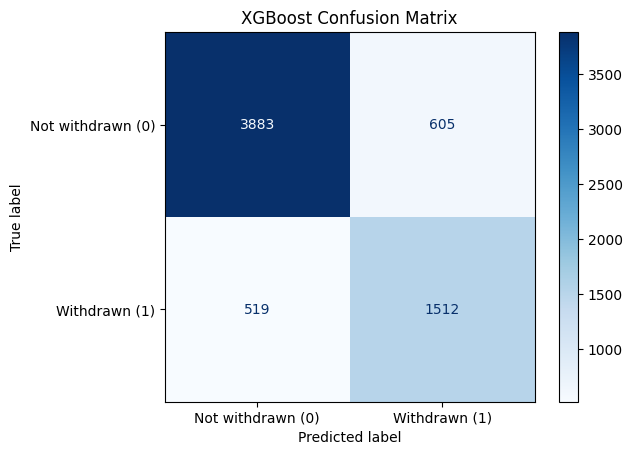

In [ ]:
###confussion matrics and false positives/negatives
best_model_name = "XGBoost"
y_pred = predictions[best_model_name]

cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

print("True Negatives:", tn)
print("False Positives:", fp)
print("False Negatives:", fn)
print("True Positives:", tp)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not withdrawn (0)", "Withdrawn (1)"]
).plot(cmap="Blues")

plt.title(f"{best_model_name} Confusion Matrix")
plt.show()

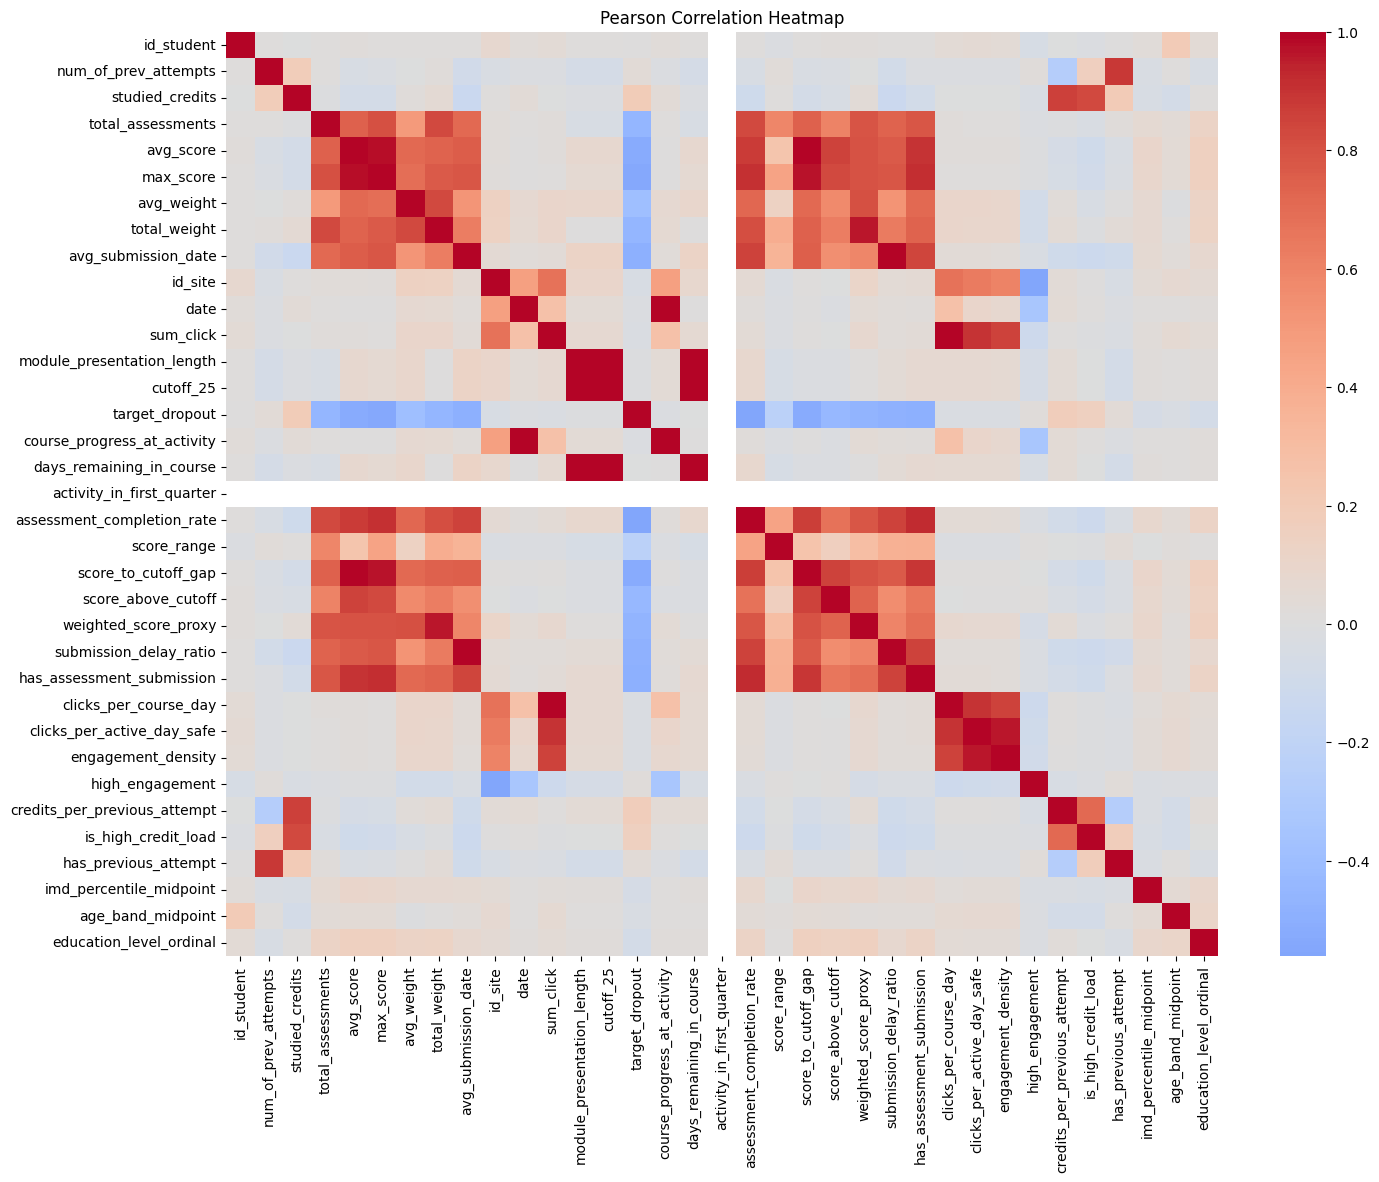

,Correlation with dropout
assessment_completion_rate,-0.560322
max_score,-0.536371
score_to_cutoff_gap,-0.527200
avg_score,-0.526407
has_assessment_submission,-0.498274
avg_submission_date,-0.487368
submission_delay_ratio,-0.487065
weighted_score_proxy,-0.470349
total_assessments,-0.453250
total_weight,-0.451254


In [ ]:
###Person relation and heatmap,
numeric_data = df.select_dtypes(include=["number"]).drop(
    columns=["target_encoded"], errors="ignore"
)

correlation = numeric_data.corr(method="pearson")

plt.figure(figsize=(16, 12))
sns.heatmap(correlation, cmap="coolwarm", center=0)
plt.title("Pearson Correlation Heatmap")
plt.show()

dropout_correlation = (
    correlation["target_dropout"]
    .drop("target_dropout")
    .sort_values(key=lambda x: abs(x), ascending=False)
)

display(dropout_correlation.head(15).to_frame("Correlation with dropout"))

Bias and fairness metrics by gender, disability, age, and education:

In [ ]:
def fairness_by_group(group_column, actual, predicted):
    fairness_data = df.loc[X_test.index, [group_column]].copy()
    fairness_data["actual"] = actual.values
    fairness_data["predicted"] = predicted
    
    results = []
    
    for group, part in fairness_data.groupby(group_column):
        tn, fp, fn, tp = confusion_matrix(
            part["actual"], part["predicted"], labels=[0, 1]
        ).ravel()
        
        results.append({
            "Group": group,
            "Students": len(part),
            "Demographic parity": part["predicted"].mean(),
            "Equal opportunity (TPR)": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            "False positive rate": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "Accuracy": (tp + tn) / len(part)
        })
    
    return pd.DataFrame(results).round(4)

for feature in ["gender", "disability", "age_band", "highest_education"]:
    print(f"\nFairness results by {feature}:")
    display(fairness_by_group(feature, y_test, predictions["XGBoost"]))


Fairness results by gender:


,Group,Students,Demographic parity,Equal opportunity (TPR),False positive rate,Accuracy
0,F,3000,0.3017,0.7398,0.1106,0.8440
1,M,3519,0.3444,0.7482,0.1559,0.8136



Fairness results by disability:


,Group,Students,Demographic parity,Equal opportunity (TPR),False positive rate,Accuracy
0,N,5899,0.3114,0.7420,0.1267,0.8339
1,Y,620,0.4516,0.7615,0.2278,0.7677



Fairness results by age_band:


,Group,Students,Demographic parity,Equal opportunity (TPR),False positive rate,Accuracy
0,0-35,4593,0.3338,0.7466,0.1375,0.8252
1,35-55,1875,0.3040,0.7388,0.1299,0.8325
2,55<=,51,0.2745,0.7333,0.0833,0.8627



Fairness results by highest_education:


,Group,Students,Demographic parity,Equal opportunity (TPR),False positive rate,Accuracy
0,A Level or Equivalent,2750,0.2800,0.7104,0.1147,0.8367
1,HE Qualification,942,0.2877,0.7249,0.1129,0.8408
2,Lower Than A Level,2689,0.3842,0.7811,0.1673,0.8144
3,No Formal quals,74,0.4324,0.7500,0.1316,0.8108
4,Post Graduate Qualification,64,0.1719,0.4615,0.0980,0.8125


###SMOTE, class weights, oversampling, and undersampling comparison:

In [ ]:
%pip install -U imbalanced-learn

Note: you may need to restart the kernel to use updated packages.


In [ ]:
import imblearn
print("imblearn version:", imblearn.__version__)

imblearn version: 0.14.2


In [ ]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

balance_models = {
    "No balancing": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    
    "Class weights": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=2000, class_weight="balanced", random_state=42
        ))
    ]),
    
    "SMOTE": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", SMOTE(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    
    "Random oversampling": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", RandomOverSampler(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ]),
    
    "Random undersampling": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", RandomUnderSampler(random_state=42)),
        ("model", LogisticRegression(max_iter=2000, random_state=42))
    ])
}

balance_results = []

for name, model in balance_models.items():
    metrics, _, _, _ = evaluate_model(name, model)
    balance_results.append(metrics)

display(
    pd.DataFrame(balance_results)
    .sort_values("ROC-AUC", ascending=False)
    .round(4)
)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,Random oversampling,0.8175,0.6959,0.7356,0.7152,0.8623
1,Class weights,0.8176,0.6965,0.7346,0.7151,0.8621
0,No balancing,0.8328,0.7796,0.6460,0.7065,0.8618
2,SMOTE,0.8181,0.6973,0.7351,0.7157,0.8617
4,Random undersampling,0.8170,0.6951,0.7351,0.7145,0.8616


Neural network / MLP:

In [ ]:
mlp_model = Pipeline([
    ("preprocessor", preprocessor_scaled),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        alpha=0.001,
        early_stopping=True,
        max_iter=300,
        random_state=42
    ))
])

mlp_metrics, _, _, _ = evaluate_model("Neural Network (MLP)", mlp_model)
display(pd.DataFrame([mlp_metrics]).round(4))

,Model,Accuracy,Precision,Recall,F1,ROC-AUC
0,Neural Network (MLP),0.8348,0.7887,0.6416,0.7076,0.8652


In [ ]:
xgb_pipeline = fitted_models["XGBoost"]

feature_names = xgb_pipeline.named_steps[
    "preprocessor"
].get_feature_names_out()

importance = xgb_pipeline.named_steps[
    "model"
].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importance
}).sort_values("Importance", ascending=False)

display(feature_importance.head(20))

,Feature,Importance
14,num__assessment_completion_rate,0.503229
37,cat__code_module_GGG,0.070890
19,num__submission_delay_ratio,0.015606
6,num__total_weight,0.012692
3,num__avg_score,0.012573
4,num__max_score,0.012399
11,num__cutoff_25,0.009756
41,cat__code_presentation_2014J,0.009639
1,num__studied_credits,0.008746
16,num__score_to_cutoff_gap,0.008535


In [ ]:
feature_importance = feature_importance.sort_values(
    "Importance",
    ascending=False
).reset_index(drop=True)

feature_importance.index = feature_importance.index + 1
feature_importance.index.name = "Rank"

display(feature_importance.head(20))

,Feature,Importance
Rank,,
1,num__assessment_completion_rate,0.503229
2,cat__code_module_GGG,0.070890
3,num__submission_delay_ratio,0.015606
4,num__total_weight,0.012692
5,num__avg_score,0.012573
6,num__max_score,0.012399
7,num__cutoff_25,0.009756
8,cat__code_presentation_2014J,0.009639
9,num__studied_credits,0.008746


In [ ]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix
)

# HistGradientBoosting needs dense (not sparse) one-hot encoded features
preprocessor_histxgb = ColumnTransformer([
    ("num", StandardScaler(), numeric_columns),
    ("cat", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    ), categorical_columns)
])

# Balance the withdrawal class using sample weights
# 1 = Withdrawn; 0 = Not withdrawn
class_weight_0 = 1
class_weight_1 = (y_train == 0).sum() / (y_train == 1).sum()

sample_weights = y_train.map({
    0: class_weight_0,
    1: class_weight_1
})

# HistGradientBoosting model
histxgb_model = Pipeline([
    ("preprocessor", preprocessor_histxgb),
    ("model", HistGradientBoostingClassifier(
        learning_rate=0.05,
        max_iter=300,
        max_leaf_nodes=31,
        l2_regularization=1.0,
        random_state=42
    ))
])

# Train model
histxgb_model.fit(
    X_train,
    y_train,
    model__sample_weight=sample_weights
)

# Predictions
histxgb_pred = histxgb_model.predict(X_test)
histxgb_probability = histxgb_model.predict_proba(X_test)[:, 1]

# Evaluation
print("HistGradientBoosting Accuracy:",
      round(accuracy_score(y_test, histxgb_pred), 4))

print("HistGradientBoosting Precision:",
      round(precision_score(y_test, histxgb_pred), 4))

print("HistGradientBoosting Recall:",
      round(recall_score(y_test, histxgb_pred), 4))

print("HistGradientBoosting F1-score:",
      round(f1_score(y_test, histxgb_pred), 4))

print("HistGradientBoosting ROC-AUC:",
      round(roc_auc_score(y_test, histxgb_probability), 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, histxgb_pred))

HistGradientBoosting Accuracy: 0.826
HistGradientBoosting Precision: 0.7107
HistGradientBoosting Recall: 0.745
HistGradientBoosting F1-score: 0.7274
HistGradientBoosting ROC-AUC: 0.8716

Confusion Matrix:
[[3872  616]
 [ 518 1513]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# Predictions from the trained XGBoost model
y_pred = xgboost_model.predict(X_test)

# Add actual and predicted values to the original test rows
fairness_data = df.loc[X_test.index, [
    "gender",
    "disability",
    "age_band",
    "highest_education"
]].copy()

fairness_data["actual_dropout"] = y_test.values
fairness_data["predicted_dropout"] = y_pred

def calculate_fairness_metrics(data, group_column):
    results = []

    for group, part in data.groupby(group_column, dropna=False):
        tn, fp, fn, tp = confusion_matrix(
            part["actual_dropout"],
            part["predicted_dropout"],
            labels=[0, 1]
        ).ravel()

        results.append({
            "Sensitive Feature": group_column,
            "Group": group,
            "Students": len(part),
            "Accuracy": (tp + tn) / len(part),
            
            # Demographic parity:
            # percentage predicted as dropout
            "Selection Rate": (tp + fp) / len(part),
            
            # Equal opportunity:
            # percentage of actual dropouts correctly detected
            "TPR / Recall": tp / (tp + fn) if (tp + fn) > 0 else np.nan,
            
            # Percentage of non-dropouts incorrectly predicted as dropout
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            
            # Equalized odds uses both TPR and FPR
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })

    return pd.DataFrame(results)

# Calculate fairness metrics for every sensitive attribute
sensitive_features = [
    "gender",
    "disability",
    "age_band",
    "highest_education"
]

fairness_tables = []

for feature in sensitive_features:
    fairness_tables.append(
        calculate_fairness_metrics(fairness_data, feature)
    )

# One combined comparison table
fairness_comparison = pd.concat(
    fairness_tables,
    ignore_index=True
)

fairness_comparison = fairness_comparison.sort_values(
    by=["Sensitive Feature", "Group"]
).reset_index(drop=True)

# Round percentages/metrics for display
fairness_comparison[
    ["Accuracy", "Selection Rate", "TPR / Recall", "FPR"]
] = fairness_comparison[
    ["Accuracy", "Selection Rate", "TPR / Recall", "FPR"]
].round(4)

display(fairness_comparison)

# Save table for dissertation
fairness_comparison.to_csv(
    "fairness_comparison_results.csv",
    index=False
)

,Sensitive Feature,Group,Students,Accuracy,Selection Rate,TPR / Recall,FPR,TP,FP,FN,TN
0,age_band,0-35,4593,0.8252,0.3338,0.7466,0.1375,1105,428,375,2685
1,age_band,35-55,1875,0.8325,0.3040,0.7388,0.1299,396,174,140,1165
2,age_band,55<=,51,0.8627,0.2745,0.7333,0.0833,11,3,4,33
3,disability,N,5899,0.8339,0.3114,0.7420,0.1267,1314,523,457,3605
4,disability,Y,620,0.7677,0.4516,0.7615,0.2278,198,82,62,278
5,gender,F,3000,0.8440,0.3017,0.7398,0.1106,674,231,237,1858
6,gender,M,3519,0.8136,0.3444,0.7482,0.1559,838,374,282,2025
7,highest_education,A Level or Equivalent,2750,0.8367,0.2800,0.7104,0.1147,542,228,221,1759
8,highest_education,HE Qualification,942,0.8408,0.2877,0.7249,0.1129,195,76,74,597
9,highest_education,Lower Than A Level,2689,0.8144,0.3842,0.7811,0.1673,742,291,208,1448


In [ ]:
fairness_gap_summary = fairness_comparison.groupby(
    "Sensitive Feature"
).agg(
    Groups=("Group", "count"),
    Accuracy_Gap=("Accuracy", lambda x: x.max() - x.min()),
    Selection_Rate_Gap=("Selection Rate", lambda x: x.max() - x.min()),
    TPR_Gap=("TPR / Recall", lambda x: x.max() - x.min()),
    FPR_Gap=("FPR", lambda x: x.max() - x.min())
).reset_index()

display(fairness_gap_summary.round(4))

fairness_gap_summary.to_csv(
    "fairness_gap_summary.csv",
    index=False
)

,Sensitive Feature,Groups,Accuracy_Gap,Selection_Rate_Gap,TPR_Gap,FPR_Gap
0,age_band,3,0.0375,0.0593,0.0133,0.0542
1,disability,2,0.0662,0.1402,0.0195,0.1011
2,gender,2,0.0304,0.0427,0.0084,0.0453
3,highest_education,5,0.0300,0.2605,0.3196,0.0693


In [ ]:
histxgb_result = pd.DataFrame([{
    "Model": "HistGradientBoosting",
    "Accuracy": accuracy_score(y_test, histxgb_pred),
    "Precision (Withdrawal=1)": precision_score(y_test, histxgb_pred),
    "Recall (Withdrawal=1)": recall_score(y_test, histxgb_pred),
    "F1-score (Withdrawal=1)": f1_score(y_test, histxgb_pred),
    "ROC-AUC": roc_auc_score(y_test, histxgb_probability)
}])

comparison_results = pd.concat(
    [comparison_results, histxgb_result],
    ignore_index=True
).sort_values("ROC-AUC", ascending=False)

display(comparison_results.round(4))

,Model,Accuracy,Precision (Withdrawal=1),Recall (Withdrawal=1),F1-score (Withdrawal=1),ROC-AUC
4,HistGradientBoosting,0.8260,0.7107,0.7450,0.7274,0.8716
0,XGBoost,0.8276,0.7142,0.7445,0.7290,0.8703
1,Random Forest,0.8336,0.7489,0.7006,0.7240,0.8674
2,Logistic Regression,0.8176,0.6965,0.7346,0.7151,0.8621
3,Baseline,0.6884,0.0000,0.0000,0.0000,0.5000


In [ ]:
# Run once, if needed:
# %pip install -U scikit-learn imbalanced-learn xgboost

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# --------------------------------------------------
# 1. Load data and prepare features
# --------------------------------------------------
df = pd.read_csv("master_25_filled_featured.csv")

TARGET = "target_dropout"  # 0 = not withdrawn, 1 = withdrawn

# Remove labels/outcomes that cause data leakage, IDs, and constant feature
DROP_COLUMNS = [
    "target_dropout",
    "target_encoded",
    "final_result",
    "id_student",
    "activity_in_first_quarter"
]

X = df.drop(columns=DROP_COLUMNS).copy()
y = df[TARGET].copy()

# id_site is a category, not a continuous number
X["id_site"] = X["id_site"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Scaling is useful for Logistic Regression and MLP
preprocessor_scaled = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_columns),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

# Trees do not require numeric scaling
preprocessor_tree = ColumnTransformer([
    ("numeric", "passthrough", numeric_columns),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

# Ratio used to give extra weight to withdrawal class (1)
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# --------------------------------------------------
# 2. Define all models
# --------------------------------------------------
models = {
    
    "Logistic Regression (No balancing)": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),
    
    "Logistic Regression (Class weights)": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),
    
    "Logistic Regression (SMOTE)": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),
    
    "Logistic Regression (Random oversampling)": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", RandomOverSampler(random_state=42)),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),
    
    "Logistic Regression (Random undersampling)": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", RandomUnderSampler(random_state=42)),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),
    
    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ]),
    
    "MLP Neural Network": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=0.001,
            early_stopping=True,
            max_iter=300,
            random_state=42
        ))
    ]),
    
}

# --------------------------------------------------
# 3. Train every model and create one comparison table
# --------------------------------------------------
results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]
    
    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Withdrawal=1)": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall (Withdrawal=1)": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-score (Withdrawal=1)": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })
    
    trained_models[model_name] = model

# --------------------------------------------------
# 4. Display and save results
# --------------------------------------------------
all_models_performance = pd.DataFrame(results)

all_models_performance = all_models_performance.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(all_models_performance.round(4))

all_models_performance.to_csv(
    "all_models_performance_comparison.csv",
    index=False
)

print("Saved: all_models_performance_comparison.csv")

Training: Logistic Regression (No balancing)
Training: Logistic Regression (Class weights)
Training: Logistic Regression (SMOTE)
Training: Logistic Regression (Random oversampling)
Training: Logistic Regression (Random undersampling)
Training: Random Forest
Training: XGBoost
Training: MLP Neural Network


,Model,Accuracy,Precision (Withdrawal=1),Recall (Withdrawal=1),F1-score (Withdrawal=1),ROC-AUC
0,XGBoost,0.8276,0.7142,0.7445,0.7290,0.8703
1,Random Forest,0.8336,0.7489,0.7006,0.7240,0.8674
2,MLP Neural Network,0.8348,0.7887,0.6416,0.7076,0.8652
3,Logistic Regression (Random oversampling),0.8175,0.6959,0.7356,0.7152,0.8623
4,Logistic Regression (Class weights),0.8176,0.6965,0.7346,0.7151,0.8621
5,Logistic Regression (No balancing),0.8328,0.7796,0.6460,0.7065,0.8618
6,Logistic Regression (SMOTE),0.8181,0.6973,0.7351,0.7157,0.8617
7,Logistic Regression (Random undersampling),0.8170,0.6951,0.7351,0.7145,0.8616


Saved: all_models_performance_comparison.csv


In [ ]:
# Run once if needed:
# %pip install -U scikit-learn imbalanced-learn xgboost

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score
)

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from xgboost import XGBClassifier

# -------------------------------------------------------
# 1. Load and prepare data
# -------------------------------------------------------
df = pd.read_csv("master_25_filled_featured.csv")

TARGET = "target_dropout"  # 0 = not withdrawn, 1 = withdrawn

DROP_COLUMNS = [
    "target_dropout",
    "target_encoded",       # target leakage
    "final_result",         # target leakage
    "id_student",           # identifier
    "activity_in_first_quarter"  # constant feature
]

X = df.drop(columns=DROP_COLUMNS).copy()
y = df[TARGET].copy()

# Treat site ID as categorical
X["id_site"] = X["id_site"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# Numeric scaling: required/useful for Logistic Regression and MLP
preprocessor_scaled = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_columns),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

# Tree models do not need numeric scaling
preprocessor_tree = ColumnTransformer([
    ("numeric", "passthrough", numeric_columns),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

# HistGradientBoosting needs dense data, not sparse one-hot encoding
preprocessor_hist = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_columns),
    ("categorical", OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False  # If error, change to sparse=False
    ), categorical_columns)
])

# Class imbalance ratio
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# HistGradientBoosting uses sample weights instead of class_weight
hist_sample_weight = y_train.map({
    0: 1,
    1: scale_pos_weight
})

# -------------------------------------------------------
# 2. Define ALL models
# Note: "Linear Regression" is not suitable for binary
# dropout. Logistic Regression is the correct linear model.
# -------------------------------------------------------
models = {

    "Logistic Regression (No balancing)": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Logistic Regression (Class weights)": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "Logistic Regression (SMOTE)": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", SMOTE(random_state=42)),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Logistic Regression (Random oversampling)": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", RandomOverSampler(random_state=42)),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Logistic Regression (Random undersampling)": ImbPipeline([
        ("preprocessor", preprocessor_scaled),
        ("sampler", RandomUnderSampler(random_state=42)),
        ("model", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "XGBoost": Pipeline([
        ("preprocessor", preprocessor_tree),
        ("model", XGBClassifier(
            n_estimators=400,
            max_depth=5,
            learning_rate=0.05,
            subsample=0.8,
            colsample_bytree=0.8,
            scale_pos_weight=scale_pos_weight,
            objective="binary:logistic",
            eval_metric="logloss",
            tree_method="hist",
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "HistGradientBoosting": Pipeline([
        ("preprocessor", preprocessor_hist),
        ("model", HistGradientBoostingClassifier(
            learning_rate=0.05,
            max_iter=300,
            max_leaf_nodes=31,
            l2_regularization=1.0,
            random_state=42
        ))
    ]),

    "MLP Neural Network": Pipeline([
        ("preprocessor", preprocessor_scaled),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            alpha=0.001,
            early_stopping=True,
            max_iter=300,
            random_state=42
        ))
    ])
}

# -------------------------------------------------------
# 3. Train all models and collect performance metrics
# -------------------------------------------------------
results = []
trained_models = {}

for model_name, model in models.items():
    print(f"Training: {model_name}")

    # HistGradientBoosting needs sample weights for imbalance
    if model_name == "HistGradientBoosting":
        model.fit(
            X_train,
            y_train,
            model__sample_weight=hist_sample_weight
        )
    else:
        model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_probability = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision (Withdrawal=1)": precision_score(
            y_test, y_pred, zero_division=0
        ),
        "Recall (Withdrawal=1)": recall_score(
            y_test, y_pred, zero_division=0
        ),
        "F1-score (Withdrawal=1)": f1_score(
            y_test, y_pred, zero_division=0
        ),
        "ROC-AUC": roc_auc_score(y_test, y_probability)
    })

    trained_models[model_name] = model

# -------------------------------------------------------
# 4. Display and save one complete comparison table
# -------------------------------------------------------
all_models_performance = pd.DataFrame(results)

all_models_performance = all_models_performance.sort_values(
    by="ROC-AUC",
    ascending=False
).reset_index(drop=True)

display(all_models_performance.round(4))

all_models_performance.to_csv(
    "all_models_performance_comparison.csv",
    index=False
)

print("Saved: all_models_performance_comparison.csv")

Training: Logistic Regression (No balancing)
Training: Logistic Regression (Class weights)
Training: Logistic Regression (SMOTE)
Training: Logistic Regression (Random oversampling)
Training: Logistic Regression (Random undersampling)
Training: Random Forest
Training: XGBoost
Training: HistGradientBoosting
Training: MLP Neural Network


,Model,Accuracy,Precision (Withdrawal=1),Recall (Withdrawal=1),F1-score (Withdrawal=1),ROC-AUC
0,HistGradientBoosting,0.8260,0.7107,0.7450,0.7274,0.8716
1,XGBoost,0.8276,0.7142,0.7445,0.7290,0.8703
2,Random Forest,0.8336,0.7489,0.7006,0.7240,0.8674
3,MLP Neural Network,0.8348,0.7887,0.6416,0.7076,0.8652
4,Logistic Regression (Random oversampling),0.8175,0.6959,0.7356,0.7152,0.8623
5,Logistic Regression (Class weights),0.8176,0.6965,0.7346,0.7151,0.8621
6,Logistic Regression (No balancing),0.8328,0.7796,0.6460,0.7065,0.8618
7,Logistic Regression (SMOTE),0.8181,0.6973,0.7351,0.7157,0.8617
8,Logistic Regression (Random undersampling),0.8170,0.6951,0.7351,0.7145,0.8616


Saved: all_models_performance_comparison.csv


In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# ---------------------------------------------------------
# 1. Load data
# ---------------------------------------------------------
df = pd.read_csv("master_25_filled_featured.csv")

TARGET = "target_dropout"   # 1 = Withdrawn, 0 = Not withdrawn

# Sensitive features to audit one by one
sensitive_features = [
    "gender",
    "disability",
    "age_band",
    "highest_education"
]

# Remove target leakage, identifiers, constants and sensitive features
# Sensitive features are excluded from training but used for fairness testing.
DROP_COLUMNS = [
    "target_dropout",
    "target_encoded",
    "final_result",
    "id_student",
    "activity_in_first_quarter"
] + sensitive_features

X = df.drop(columns=DROP_COLUMNS).copy()
y = df[TARGET].copy()

# Site ID is categorical
X["id_site"] = X["id_site"].astype(str)

# Keep sensitive features separately for fairness evaluation
sensitive_data = df[sensitive_features].copy()

# ---------------------------------------------------------
# 2. Train-test split
# ---------------------------------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

categorical_columns = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

numeric_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

# ---------------------------------------------------------
# 3. Train a model
# You may replace Logistic Regression with XGBoost later.
# ---------------------------------------------------------
preprocessor = ColumnTransformer([
    ("numeric", StandardScaler(), numeric_columns),
    ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_columns)
])

fairness_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=2000,
        class_weight="balanced",
        random_state=42
    ))
])

fairness_model.fit(X_train, y_train)

y_pred = fairness_model.predict(X_test)

print("Overall test accuracy:", round(accuracy_score(y_test, y_pred), 4))

Overall test accuracy: 0.8185


In [ ]:
# ---------------------------------------------------------
# 4. Function to calculate DPD and EOD
# ---------------------------------------------------------
def calculate_fairness_metrics(y_true, y_pred, group_values, feature_name):
    
    results = []
    
    fairness_df = pd.DataFrame({
        "Group": group_values.astype(str).fillna("Unknown"),
        "Actual": y_true.values,
        "Predicted": y_pred
    })
    
    for group, data in fairness_df.groupby("Group"):
        
        tn, fp, fn, tp = confusion_matrix(
            data["Actual"],
            data["Predicted"],
            labels=[0, 1]
        ).ravel()
        
        # Demographic parity uses predicted dropout rate
        selection_rate = (tp + fp) / len(data)
        
        # Equal opportunity uses true positive rate / recall
        tpr = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        
        # False-positive rate is useful for equalized odds
        fpr = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        
        results.append({
            "Sensitive Feature": feature_name,
            "Group": group,
            "Students": len(data),
            "Accuracy": (tp + tn) / len(data),
            "Predicted Dropout Rate": selection_rate,
            "TPR / Recall": tpr,
            "FPR": fpr,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })
    
    group_table = pd.DataFrame(results)
    
    # DPD = largest predicted-dropout-rate difference between groups
    dpd = (
        group_table["Predicted Dropout Rate"].max()
        - group_table["Predicted Dropout Rate"].min()
    )
    
    # EOD = largest recall/TPR difference between groups
    eod = (
        group_table["TPR / Recall"].max()
        - group_table["TPR / Recall"].min()
    )
    
    # Equalized Odds Difference: largest difference in TPR or FPR
    fpr_gap = (
        group_table["FPR"].max()
        - group_table["FPR"].min()
    )
    
    equalized_odds_difference = max(eod, fpr_gap)
    
    return group_table, dpd, eod, fpr_gap, equalized_odds_difference

In [ ]:
# ---------------------------------------------------------
# 5. Check fairness one sensitive feature at a time
# ---------------------------------------------------------
all_group_results = []
fairness_summary = []

for feature in sensitive_features:
    
    # Group membership only for students in the test set
    test_groups = sensitive_data.loc[X_test.index, feature]
    
    group_table, dpd, eod, fpr_gap, equalized_odds_difference = (
        calculate_fairness_metrics(
            y_test,
            y_pred,
            test_groups,
            feature
        )
    )
    
    all_group_results.append(group_table)
    
    fairness_summary.append({
        "Sensitive Feature": feature,
        "DPD": dpd,
        "EOD (TPR Gap)": eod,
        "FPR Gap": fpr_gap,
        "Equalized Odds Difference": equalized_odds_difference
    })

# Detailed group-level table
fairness_group_results = pd.concat(
    all_group_results,
    ignore_index=True
).round(4)

# One comparison table for DPD and EOD
fairness_comparison = pd.DataFrame(
    fairness_summary
).round(4)

print("Detailed fairness results by group:")
display(fairness_group_results)

print("Fairness comparison table:")
display(fairness_comparison)

# Save results
fairness_group_results.to_csv(
    "fairness_group_results.csv",
    index=False
)

fairness_comparison.to_csv(
    "fairness_DPD_EOD_comparison.csv",
    index=False
)

Detailed fairness results by group:


,Sensitive Feature,Group,Students,Accuracy,Predicted Dropout Rate,TPR / Recall,FPR,TP,FP,FN,TN
0,gender,F,3000,0.8337,0.3053,0.7289,0.1206,664,252,247,1837
1,gender,M,3519,0.8056,0.3461,0.7384,0.1630,827,391,293,2008
2,disability,N,5899,0.8225,0.3167,0.7318,0.1386,1296,572,475,3556
3,disability,Y,620,0.7806,0.4290,0.7500,0.1972,195,71,65,289
4,age_band,0-35,4593,0.8143,0.3368,0.7345,0.1478,1087,460,393,2653
5,age_band,35-55,1875,0.8283,0.3051,0.7332,0.1337,393,179,143,1160
6,age_band,55<=,51,0.8431,0.2941,0.7333,0.1111,11,4,4,32
7,highest_education,A Level or Equivalent,2750,0.8324,0.2895,0.7195,0.1243,549,247,214,1740
8,highest_education,HE Qualification,942,0.8312,0.2718,0.6803,0.1085,183,73,86,600
9,highest_education,Lower Than A Level,2689,0.8003,0.3871,0.7653,0.1806,727,314,223,1425


Fairness comparison table:


,Sensitive Feature,DPD,EOD (TPR Gap),FPR Gap,Equalized Odds Difference
0,gender,0.0408,0.0095,0.0424,0.0424
1,disability,0.1124,0.0182,0.0587,0.0587
2,age_band,0.0427,0.0013,0.0367,0.0367
3,highest_education,0.3209,0.3806,0.1217,0.3806


Your results show that fairness differs by sensitive feature. Values closer to 0 are better.
Sensitive feature	Interpretation
Gender	Fairly consistent. DPD 0.0408 and EOD 0.0095 are low. The model detects withdrawals at nearly the same rate across genders.
Disability	Moderate disparity. Predicted dropout rates differ by 11.24% between groups. Check detailed group results before drawing conclusions.
Age band	Fairly consistent. Very low EOD (0.0013) means recall is almost identical across age groups.
Highest education	Largest fairness concern. DPD 0.3209 and EOD 0.3806 indicate substantial differences between education groups.


Most important finding:
The model showed relatively low disparities across gender and age bands. However, substantial disparities were observed across highest-education groups, with a demographic parity difference of 0.3209 and an equal-opportunity difference of 0.3806. This means that predicted dropout rates and the ability to detect actual withdrawals varied considerably by education level. Therefore, the model should be reviewed for potential educational-level bias before deployment.

Important: a high DPD does not automatically prove unfairness, because dropout rates may genuinely differ between education groups. But the high EOD = 0.3806 is more concerning because it means the model identifies real withdrawals much better for some education groups than others.

In [ ]:
display(
    fairness_group_results[
        fairness_group_results["Sensitive Feature"] == "highest_education"
    ].sort_values("TPR / Recall", ascending=False)
)

,Sensitive Feature,Group,Students,Accuracy,Predicted Dropout Rate,TPR / Recall,FPR,TP,FP,FN,TN
9,highest_education,Lower Than A Level,2689,0.8003,0.3871,0.7653,0.1806,727,314,223,1425
10,highest_education,No Formal quals,74,0.7973,0.4459,0.7500,0.1579,27,6,9,32
7,highest_education,A Level or Equivalent,2750,0.8324,0.2895,0.7195,0.1243,549,247,214,1740
8,highest_education,HE Qualification,942,0.8312,0.2718,0.6803,0.1085,183,73,86,600
11,highest_education,Post Graduate Qualification,64,0.8281,0.1250,0.3846,0.0588,5,3,8,48


The main fairness problem comes from the Post Graduate Qualification group.
Education group	Students	Recall / TPR	False negatives	Interpretation
Lower Than A Level	2,689	76.53%	223	Best withdrawal detection
No Formal quals	74	75.00%	9	High recall, but small group
A Level or Equivalent	2,750	71.95%	214	Reasonably consistent
HE Qualification	942	68.03%	86	Slightly lower recall
Post Graduate Qualification	64	38.46%	8	Model misses many actual withdrawals


For postgraduate students, there were 13 actual withdrawals (TP + FN = 5 + 8). The model detected only 5 and missed 8, producing recall of only 38.46%.
This creates the high EOD:
Highest TPR = 0.7653  (Lower Than A Level)
Lowest TPR  = 0.3846  (Post Graduate Qualification)

EOD = 0.7653 - 0.3846 = 0.3807
observation:
Fairness analysis across education groups revealed a substantial equal-opportunity disparity. The model achieved its highest recall for students with Lower Than A Level qualifications (76.53%) but only 38.46% for postgraduate-qualified students. Therefore, the model was substantially less effective at identifying postgraduate students who subsequently withdrew. However, this result should be interpreted cautiously because the postgraduate group contained only 64 students and 13 actual withdrawal cases, making the metric less stable.

The postgraduate group has a small sample size, so do not claim definite discrimination. Report it as a limitation and consider collecting more postgraduate observations or reporting confidence intervals.




In [ ]:
import numpy as np
import pandas as pd
from itertools import combinations
from sklearn.metrics import confusion_matrix

sensitive_features = [
    "gender",
    "disability",
    "age_band",
    "highest_education"
]

# Keep only the test-set rows and predictions
intersection_data = df.loc[X_test.index, sensitive_features].copy()

intersection_data["Actual"] = y_test.values
intersection_data["Predicted"] = y_pred

def intersectional_fairness(data, feature_1, feature_2, min_students=50):
    
    # Create combined groups, e.g. "F | Y"
    group_name = feature_1 + " + " + feature_2
    
    temp = data.copy()
    temp[group_name] = (
        temp[feature_1].astype(str)
        + " | "
        + temp[feature_2].astype(str)
    )
    
    results = []
    
    for group, part in temp.groupby(group_name):
        
        tn, fp, fn, tp = confusion_matrix(
            part["Actual"],
            part["Predicted"],
            labels=[0, 1]
        ).ravel()
        
        actual_dropouts = tp + fn
        
        results.append({
            "Feature Combination": group_name,
            "Group": group,
            "Students": len(part),
            "Actual Withdrawals": actual_dropouts,
            "Selection Rate": (tp + fp) / len(part),
            "TPR / Recall": tp / actual_dropouts if actual_dropouts > 0 else np.nan,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })
    
    group_results = pd.DataFrame(results)
    
    # Remove very small groups because fairness metrics become unreliable
    valid_groups = group_results[
        (group_results["Students"] >= min_students) &
        (group_results["Actual Withdrawals"] > 0)
    ].copy()
    
    # DPD = maximum difference in predicted dropout rates
    dpd = (
        valid_groups["Selection Rate"].max()
        - valid_groups["Selection Rate"].min()
    )
    
    # EOD = maximum difference in recall / TPR
    eod = (
        valid_groups["TPR / Recall"].max()
        - valid_groups["TPR / Recall"].min()
    )
    
    # FPR gap and Equalized Odds Difference
    fpr_gap = (
        valid_groups["FPR"].max()
        - valid_groups["FPR"].min()
    )
    
    equalized_odds_difference = max(eod, fpr_gap)
    
    summary = {
        "Feature Combination": group_name,
        "Valid Groups": len(valid_groups),
        "DPD": dpd,
        "EOD (TPR Gap)": eod,
        "FPR Gap": fpr_gap,
        "Equalized Odds Difference": equalized_odds_difference
    }
    
    return group_results, summary

In [ ]:
# Check every pair of sensitive features
all_intersection_groups = []
intersection_summary = []

for feature_1, feature_2 in combinations(sensitive_features, 2):
    
    group_results, summary = intersectional_fairness(
        intersection_data,
        feature_1,
        feature_2,
        min_students=50
    )
    
    all_intersection_groups.append(group_results)
    intersection_summary.append(summary)

# Detailed results for every combined group
intersection_group_results = pd.concat(
    all_intersection_groups,
    ignore_index=True
).round(4)

# One comparison table for all feature combinations
intersection_fairness_comparison = pd.DataFrame(
    intersection_summary
).sort_values(
    "EOD (TPR Gap)",
    ascending=False
).round(4)

display(intersection_fairness_comparison)

intersection_fairness_comparison.to_csv(
    "intersectional_fairness_comparison.csv",
    index=False
)

intersection_group_results.to_csv(
    "intersectional_fairness_group_results.csv",
    index=False
)

,Feature Combination,Valid Groups,DPD,EOD (TPR Gap),FPR Gap,Equalized Odds Difference
4,disability + highest_education,7,0.3209,0.3867,0.1684,0.3867
5,age_band + highest_education,7,0.2168,0.2185,0.0945,0.2185
2,gender + highest_education,6,0.1718,0.1087,0.1235,0.1235
0,gender + disability,4,0.2076,0.0616,0.1706,0.1706
1,gender + age_band,4,0.0786,0.0426,0.0571,0.0571
3,disability + age_band,5,0.1483,0.0293,0.0944,0.0944


Your intersectional fairness results show that education level is the main source of disparity.
Combination	Key finding
Disability + highest education	Largest concern: EOD 0.3867. The model’s ability to detect real withdrawals differs by about 38.7 percentage points across combined groups.
Age band + highest education	Second largest concern: EOD 0.2185. Education-related disparity remains when age is included.
Gender + highest education	Moderate concern: Equalized Odds Difference 0.1235.
Gender + disability	Highest FPR gap: 0.1706. Some groups are more likely to be incorrectly flagged as dropout.
Gender + age band	Most consistent combination: EOD 0.0426, FPR gap 0.0571.
Disability + age band	Low recall disparity: EOD 0.0293, but moderate FPR gap 0.0944.


You can write:
Intersectional fairness analysis showed that disparities were most pronounced when highest education was combined with disability status. This combination produced an Equal Opportunity Difference of 0.3867, indicating substantial variation in the model’s ability to identify actual withdrawals across intersectional groups. In contrast, the gender and age-band combination showed comparatively low disparity, with an Equal Opportunity Difference of 0.0426. These findings suggest that educational background, particularly in combination with disability status, requires further investigation before model deployment.

Important: this does not prove discrimination. Some intersectional groups may have small numbers of students or withdrawals, which makes the metric unstable. Report the group-level sample sizes alongside these fairness results.

mportant first: assessment_completion_rate has importance 0.5032, far higher than every other feature. Before reporting fairness, verify it was calculated only using information available before your prediction date. If it includes assessments completed across the full course, it may cause temporal data leakage.

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import confusion_matrix

# Use predictions from your selected model, for example:
# y_pred = xgboost_model.predict(X_test)

test_data = df.loc[X_test.index].copy()
test_data["Actual"] = y_test.values
test_data["Predicted"] = y_pred

# Features from your importance table
top_numeric_features = [
    "assessment_completion_rate",
    "submission_delay_ratio",
    "total_weight",
    "avg_score",
    "max_score",
    "cutoff_25",
    "studied_credits",
    "score_to_cutoff_gap",
    "credits_per_previous_attempt",
    "avg_weight",
    "weighted_score_proxy",
    "days_remaining_in_course",
    "module_presentation_length"
]

# Use the original categorical features, not each separate one-hot column
top_categorical_features = [
    "code_module",
    "code_presentation",
    "region"
]

def calculate_feature_fairness(data, feature, groups,
                               min_students=50,
                               min_actual_dropouts=10):
    
    temp = pd.DataFrame({
        "Group": groups.astype(str),
        "Actual": data["Actual"],
        "Predicted": data["Predicted"]
    })
    
    rows = []
    
    for group, part in temp.groupby("Group"):
        
        tn, fp, fn, tp = confusion_matrix(
            part["Actual"],
            part["Predicted"],
            labels=[0, 1]
        ).ravel()
        
        actual_dropouts = tp + fn
        
        rows.append({
            "Feature": feature,
            "Group": group,
            "Students": len(part),
            "Actual Dropouts": actual_dropouts,
            "Accuracy": (tp + tn) / len(part),
            "Predicted Dropout Rate": (tp + fp) / len(part),
            "TPR / Recall": tp / actual_dropouts if actual_dropouts > 0 else np.nan,
            "FPR": fp / (fp + tn) if (fp + tn) > 0 else np.nan,
            "TP": tp,
            "FP": fp,
            "FN": fn,
            "TN": tn
        })
    
    group_results = pd.DataFrame(rows)
    
    # Ignore small groups because fairness statistics become unstable
    valid_groups = group_results[
        (group_results["Students"] >= min_students) &
        (group_results["Actual Dropouts"] >= min_actual_dropouts)
    ].copy()
    
    dpd = (
        valid_groups["Predicted Dropout Rate"].max()
        - valid_groups["Predicted Dropout Rate"].min()
    )
    
    eod = (
        valid_groups["TPR / Recall"].max()
        - valid_groups["TPR / Recall"].min()
    )
    
    fpr_gap = (
        valid_groups["FPR"].max()
        - valid_groups["FPR"].min()
    )
    
    summary = {
        "Feature": feature,
        "Valid Groups": len(valid_groups),
        "DPD": dpd,
        "EOD (TPR Gap)": eod,
        "FPR Gap": fpr_gap,
        "Equalized Odds Difference": max(eod, fpr_gap)
    }
    
    return group_results, summary

In [ ]:
# Numerical-feature checks:
# Each feature is divided into four groups: Low, Medium-Low,
# Medium-High and High.

all_feature_group_results = []
feature_fairness_summary = []

for feature in top_numeric_features:
    
    if feature in test_data.columns:
        
        groups = pd.qcut(
            test_data[feature],
            q=4,
            duplicates="drop"
        )
        
        group_results, summary = calculate_feature_fairness(
            test_data,
            feature,
            groups
        )
        
        all_feature_group_results.append(group_results)
        feature_fairness_summary.append(summary)

# Categorical-feature checks:
for feature in top_categorical_features:
    
    if feature in test_data.columns:
        
        group_results, summary = calculate_feature_fairness(
            test_data,
            feature,
            test_data[feature].fillna("Unknown")
        )
        
        all_feature_group_results.append(group_results)
        feature_fairness_summary.append(summary)

# One comparison table for all important features
important_feature_fairness = pd.DataFrame(
    feature_fairness_summary
).sort_values(
    "EOD (TPR Gap)",
    ascending=False
).reset_index(drop=True)

display(important_feature_fairness.round(4))

# Detailed groups, for example Low / Medium / High assessment completion
important_feature_group_details = pd.concat(
    all_feature_group_results,
    ignore_index=True
)

important_feature_fairness.to_csv(
    "important_feature_performance_fairness.csv",
    index=False
)

important_feature_group_details.to_csv(
    "important_feature_group_details.csv",
    index=False
)

,Feature,Valid Groups,DPD,EOD (TPR Gap),FPR Gap,Equalized Odds Difference
0,weighted_score_proxy,3,0.6329,0.8921,0.3674,0.8921
1,avg_weight,3,0.4291,0.8283,0.1665,0.8283
2,total_weight,3,0.5274,0.8175,0.2556,0.8175
3,max_score,4,0.8185,0.7784,0.5469,0.7784
4,submission_delay_ratio,4,0.7585,0.7613,0.4608,0.7613
5,score_to_cutoff_gap,4,0.7864,0.6961,0.5247,0.6961
6,avg_score,4,0.7904,0.6772,0.5315,0.6772
7,code_module,7,0.4970,0.5855,0.2947,0.5855
8,assessment_completion_rate,2,0.7214,0.5770,0.5090,0.5770
9,region,13,0.1602,0.2271,0.0534,0.2271


To inspect assessment_completion_rate specifically:

In [ ]:
display(
    important_feature_group_details[
        important_feature_group_details["Feature"]
        == "assessment_completion_rate"
    ].round(4)
)

,Feature,Group,Students,Actual Dropouts,Accuracy,Predicted Dropout Rate,TPR / Recall,FPR,TP,FP,FN,TN
0,assessment_completion_rate,"(-0.001, 0.333]",1691,1198,0.8054,0.8616,0.9708,0.5963,1163,294,35,199
1,assessment_completion_rate,"(0.333, 1.0]",4828,833,0.8231,0.1402,0.3938,0.0874,328,349,505,3646


This result shows a very large performance difference between the two assessment-completion groups.
Assessment completion rate	Students	Actual dropout rate	Recall / TPR	FPR	Main finding
0–0.333	1,691	70.8%	97.08%	59.63%	Almost all withdrawals are detected, but many non-withdrawn students are incorrectly flagged.
0.333–1.0	4,828	17.3%	39.38%	8.74%	Fewer false alarms, but the model misses many real withdrawals (505 false negatives).


The gaps are:
DPD = 0.8616 - 0.1402 = 0.7214
EOD = 0.9708 - 0.3938 = 0.5770
FPR Gap = 0.5963 - 0.0874 = 0.5089
Interpretation:
The model performs very differently according to assessment completion rate. Students with low assessment completion are much more likely to be predicted as withdrawn, with a predicted dropout rate of 86.16%. The model identifies 97.08% of actual withdrawals in this group, but produces a high false-positive rate of 59.63%. For students with higher assessment completion, recall falls to 39.38%, meaning that many actual withdrawals are missed.

This is not demographic unfairness, because assessment completion is a behavioural/academic feature, not a protected characteristic. It is a useful performance-slice result.
However, this is also a strong temporal-leakage warning. If assessment_completion_rate was calculated using assessment data from the entire course, the model may effectively learn:
Students who stop submitting assessments are likely to withdraw.

That information may only become known near or after withdrawal. For a genuine early-warning system, calculate this feature only up to a fixed date, such as the first 25% of the course duration.


